# **Prediction of the presence of secretory signal peptides in proteins with computational methods**

**Author:** Elisa Bonanni

**Abstract**: Recognizing the presence of the signal peptide provides valuable insights, enabling predictions about the protein's potential function and its subcellular localization.
This work presents the implementation and comparison of three methods for signal peptide detec-tion in protein sequences: a simple statistical approach based on the von Heijne model, a machine learning method using Super Vector Machines (SVM) trained on hand-crafted sequence features and a second SVM trained on protein embeddings extracted with ESM-2 language model. The results obtained demonstrate a good performance for all the methods, with the latter showing lower error. For the three models, most of the false positives were found to be associated with transmembrane sequences, probably due to the similarity with the hydrophobic region of the sig-nal peptides.

> **Note:** The following codes can be executed as a unique notebook in GoogleColab environment, with exception of part 2 which is not correctly supported (which can be executed locally). The different part can be also executed separately as needed thanks to several intermediate files saved during the process.


# **1. Dataset Retrieval**
Retrieve positive and negatives datasets from UniProt API.

**Positive Dataset (Containing Signal Peptide)**
**Filters:**
* **Organisms:** Eukaryotes only
* **Reviewed / Swiss-Prot**
* **Protein Length:** ≥ 40 residues, **no fragments**
* **Signal Peptide (SP):** Experimental evidence required, length ≥ 14 residues

**TSV Output Columns:**
1. UniProt Accession
2. Organism Name
3. Eukaryotic Kingdom (Metazoa, Fungi, Plants, Other)
4. Protein Length
5. Signal Peptide Cleavage Site Position

---

**Negative Dataset (No Signal Peptide)**

**Filters:**
* **Organisms:** Eukaryotes only
* **Reviewed / Swiss-Prot**
* **Protein Length:** ≥ 40 residues
* **Signal Peptide:** **No SP** (exclude all experimental, predicted, or computational annotations)
* **Localization:** Experimentally verified in cytosol, nucleus, mitochondrion, plastid, peroxisome, or cell membrane

**TSV Output Columns:**
1. UniProt Accession
2. Organism Name
3. Eukaryotic Kingdom (Metazoa, Fungi, Plants, Other)
4. Protein Length
5. Transmembrane Helix in First 90 Residues (`True` / `False`)

In [1]:
import requests
from requests.adapters import HTTPAdapter, Retry
import json
import re

In [2]:
# Define HTTP session
retries = Retry(total=5, backoff_factor=0.25, status_forcelist=[500, 502, 503, 504]) #Number of retries
session = requests.Session()
session.mount("https://", HTTPAdapter(max_retries=retries))

def get_next_link(headers):
    """Extracts the pagination URL for the next batch from UniProt HTTP headers."""
    if "Link" in headers:
        re_next_link = re.compile(r'<(.+)>; rel="next"')
        match = re_next_link.match(headers["Link"])
        if match:
            return match.group(1)
    return None

def get_batch(batch_url):
    """Yields paginated API responses along with total entry counts."""
    while batch_url:
        response = session.get(batch_url)
        response.raise_for_status()
        total = response.headers.get("x-total-results", 0)
        yield response, total
        batch_url = get_next_link(response.headers)

def get_kingdom(lineage):
    """Determines the eukaryotic kingdom from organism taxonomic lineage."""
    if "Metazoa" in lineage:
        return "Metazoa"
    elif "Fungi" in lineage:
        return "Fungi"
    elif "Viridiplantae" in lineage:
        return "Viridiplantae"
    return "Other"

In [3]:
def get_dataset(search_url, extract_function, output_file_tsv, output_file_fasta, filter_function=None):
    """Download data from UniProt API and write it to a TSV and FASTA file."""
    n_total, n_kept = 0, 0
    with open(output_file_tsv, "w") as otsv, open(output_file_fasta, "w") as ofasta:
        for batch, total in get_batch(search_url):
            batch_json = json.loads(batch.text)
            for entry in batch_json["results"]:
                n_total += 1
                if filter_function is not None and not filter_function(entry):
                    continue
                n_kept += 1
                tsv_fields, accession, sequence = extract_function(entry)
                print(*tsv_fields, sep="\t", file=otsv)
                print(f">{accession}\n{sequence}", file=ofasta)

    print(f"{output_file_tsv}: Total={n_total}, Kept={n_kept}")

### **Positive Dataset**

In [4]:
batch_size = 500

positive_url = (
    "https://rest.uniprot.org/uniprotkb/search?format=json&query="
    "%28%28taxonomy_id%3A2759%29+AND+%28length%3A%5B40+TO+*%5D%29+"
    "AND+%28reviewed%3Atrue%29+AND+%28ft_signal_exp%3A*%29+"
    "AND+%28existence%3A1%29+AND+%28fragment%3Afalse%29%29"
    f"&size={batch_size}"
)

def filter_positive(entry):
    """Entry with signal peptide > 13 residues"""
    for feature in entry["features"]:
        if feature["type"] == "Signal":
            if isinstance(feature["location"]["end"]["value"], int):
                if feature["description"] == "":
                    if feature["location"]["end"]["value"] > 13:
                        return True
    return False


def extract_positive(entry):
    """Accession, organism, kingdom, length, cleavage position."""
    kingdom = get_kingdom(entry["organism"]["lineage"])
    signal_feature = next(f for f in entry["features"] if f.get("type") == "Signal")
    cleavage_site = signal_feature["location"]["end"]["value"]
    tsv_fields = (
        entry["primaryAccession"],
        entry["organism"]["scientificName"],
        kingdom,
        entry["sequence"]["length"],
        cleavage_site,
    )
    return tsv_fields, entry["primaryAccession"], entry["sequence"]["value"]

In [6]:
get_dataset(
    positive_url,
    extract_positive,
    "positive.tsv",
    "positive.fasta",
    filter_function=filter_positive,
)

positive.tsv: Total=2971, Kept=2952


### **Negative Dataset**

In [ ]:
negative_url = (
    "https://rest.uniprot.org/uniprotkb/search?format=json&query="
    "%28%28taxonomy_id%3A2759%29+AND+%28length%3A%5B40+TO+*%5D%29+"
    "AND+%28fragment%3Afalse%29+AND+%28reviewed%3Atrue%29+"
    "NOT+%28ft_signal%3A*%29+AND+%28existence%3A1%29+AND+"
    "%28+%28cc_scl_term_exp%3ASL-0091%29+OR+%28cc_scl_term_exp%3ASL-0191%29+"
    "OR+%28cc_scl_term_exp%3ASL-0173%29+OR+%28cc_scl_term_exp%3ASL-0204%29+"
    "OR+%28cc_scl_term_exp%3ASL-0039%29+OR+%28cc_scl_term_exp%3ASL-0209%29%29%29"
    f"&size={batch_size}"
)

negative_stats = {"n_total": 0, "n_tm": 0}

def extract_negative(entry):
    """Accession, organism, kingdom, length, TM in first 90 residues"""
    kingdom = get_kingdom(entry["organism"]["lineage"])
    hel = False
    for f in entry["features"]:
        if f["type"] == "Transmembrane":
            if f["location"]["start"]["value"] <= 90 and "Helical" in f.get("description", ""):
                hel = True
                break

    negative_stats["n_total"] += 1
    if hel:
        negative_stats["n_tm"] += 1

    tsv_fields = (
        entry["primaryAccession"],
        entry["organism"]["scientificName"],
        kingdom,
        entry["sequence"]["length"],
        hel,
    )
    return tsv_fields, entry["primaryAccession"], entry["sequence"]["value"]

In [ ]:
get_dataset(
    negative_url,
    extract_negative,
    "negative.tsv",
    "negative.fasta",
)

negative.tsv: Total=20944, Kept=20944


In [ ]:
print(
    f"negative.tsv: {negative_stats['n_total']} total entry, "
    f"{negative_stats['n_tm']} with TM in first 90 residues"
)

negative.tsv: 20944 total entry, 2524 with TM in first 90 residues


# **2. Filter redundant sequences**
Some sequences might be very similar between each other and can bias the analysis, for this reason redundant sequences are removed using mmseqs2.

Clusters sequences in positive.fasta and negative.fasta into connected components (single-linkage) using mmseqs2.

Sequences are grouped into the same cluster if they share at least 30% sequence identity (--min-seq-id 0.3) and 40% coverage (-c 0.4 --cov-mode 0) in a single execution step (--single-step-clustering 1), removing redundancy while retaining representative sequences.

*This command does not work in Google Colab, so it was executed locally.*

In [ ]:
# Install mmseqs to test alignment
!wget -q https://mmseqs.com/latest/mmseqs-linux-avx2.tar.gz
!tar xzf mmseqs-linux-avx2.tar.gz

os.environ["PATH"] += ":" + os.path.abspath("mmseqs/bin")

In [ ]:
#mmseqs clustering
!mmseqs easy-cluster positive.fasta pos_cluster_res tmp_pos --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1

!mmseqs easy-cluster negative.fasta neg_cluster_res tmp_neg --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1

Create directory tmp_pos
easy-cluster positive.fasta pos_cluster_res tmp_pos --min-seq-id 0.3 -c 0.4 --cov-mode 0 --cluster-mode 1 

MMseqs Version:                            	17b688d21dda57fc5f5b7286ecba7ec003d4717f
Substitution matrix                        	aa:blosum62.out,nucl:nucleotide.out
Seed substitution matrix                   	aa:VTML80.out,nucl:nucleotide.out
Sensitivity                                	4
k-mer length                               	0
Target search mode                         	0
k-score                                    	seq:2147483647,prof:2147483647
Alphabet size                              	aa:21,nucl:5
Max sequence length                        	65535
Max results per query                      	20
Split database                             	0
Split mode                                 	2
Split memory limit                         	0
Coverage threshold                         	0.4
Coverage mode                              	0
Compositional bias       

In [ ]:
# Remove temporary directories and files created by mmseqs
if os.path.exists("tmp_pos"):
    shutil.rmtree("tmp_pos")
    print("Removed tmp_pos")

if os.path.exists("tmp_neg"):
    shutil.rmtree("tmp_neg")
    print("Removed tmp_neg")

# **3. Divide dataset in training and benchmark**
Divide the dataset in:
* **Training/CrossValidation** (80%): will be used during 5 fold cross-validation
* **Benchmark** (20%): will be used as final testing of the performance

In [ ]:
import pandas as pd
import random

In [ ]:
# Extract selected ids
def read_fasta_ids(fasta_path):
    ids = []
    with open(fasta_path) as f:
        for line in f:
            if line.startswith(">"):
                ids.append(line[1:].strip())
    return ids


pos_ids = read_fasta_ids("pos_cluster_res_rep_seq.fasta")
neg_ids = read_fasta_ids("neg_cluster_res_rep_seq.fasta")

print(f"Positives: {len(pos_ids)}")
print(f"Negatives: {len(neg_ids)}")

Positives: 1101
Negatives: 9076


In [ ]:
# Extract data of selected proteins from the .tsv files
def filter_tsv_by_ids(ids, tsv_path):
    ids_set = set(ids)
    rows = []
    with open(tsv_path) as f:
        for line in f:
            accession = line.split("\t", 1)[0]
            if accession in ids_set:
                rows.append(line.rstrip("\n"))
    return rows


pos_rows = filter_tsv_by_ids(pos_ids, "positive.tsv")
neg_rows = filter_tsv_by_ids(neg_ids, "negative.tsv")

In [ ]:
# Shuffle
random.seed(10)  # to ensure reproducibility
random.shuffle(pos_rows)
random.shuffle(neg_rows)

# Split dataset in Benchmark (20%) + 5 fold cross-validation (80%)
def divide(total, num):
    end = [round(total / 100 * 20)]
    while num > 1:
        end.append(end[-1] + round((total - end[-1]) / num))
        num -= 1
    end.append(total)
    return end


def make_bench_and_cv(rows, cv_path, bench_path):
    total = len(rows)
    idx = divide(total, 5)
    with open(cv_path, "w") as cv, open(bench_path, "w") as bench:
        for i, line in enumerate(rows, start=1):
            for j in range(6):
                if j == 0:
                    if i <= idx[j]:
                        print(line, file=bench)
                        break
                else:
                    if i <= idx[j]:
                        print(line + "\t" + str(j), file=cv)
                        break
    return total


n_pos = make_bench_and_cv(pos_rows, "cv_pos.tsv", "bench_pos.tsv")
n_neg = make_bench_and_cv(neg_rows, "cv_neg.tsv", "bench_neg.tsv")

In [ ]:
# Summary
for name, path in [("positive", "cv_pos.tsv"), ("negative", "cv_neg.tsv")]:
    df = pd.read_csv(path, sep="\t", header=None)
    fold_col = df.columns[-1]
    counts = df[fold_col].value_counts().sort_index()
    print(f"\n{name} - distribution in 5 folds:")
    print(counts.to_string())

for name, path, total in [("positive", "bench_pos.tsv", n_pos), ("negative", "bench_neg.tsv", n_neg)]:
    n_bench = sum(1 for _ in open(path))
    print(f"\n{name}: {n_bench} benchmark entry over {total} totals "
          f"({n_bench / total:.1%})")



positive - distribution in 5 folds:
5
1    176
2    176
3    176
4    176
5    177

negative - distribution in 5 folds:
5
1    1452
2    1452
3    1452
4    1452
5    1453

positive: 220 benchmark entry over 1101 totals (20.0%)

negative: 1815 benchmark entry over 9076 totals (20.0%)


Positives and Negatives are unbalance, this must be into considation in the evaluation of the method. Accuracy won't be the best measure for this reason.

# **4. Data Visualization**
It's not sure to have an equal distribution of the properties in the different sets. So, the plots are done separated for cross-validation and benchmark sets to understand if there are biases due to the random sampling.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

!pip install logomaker
import logomaker as lm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 47.0 MB/s eta 0:00:00


In [ ]:
# Column names
col_pos_cv = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage', 'Set']
col_neg_cv = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane', 'Set']
col_pos_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage']
col_neg_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane']

# Load the TSV file into a DataFrame
pos_cv = pd.read_csv('cv_pos.tsv', sep='\t', header=None, names=col_pos_cv)
neg_cv = pd.read_csv('cv_neg.tsv', sep='\t', header=None, names=col_neg_cv)
pos_bench = pd.read_csv('bench_pos.tsv', sep='\t', header=None, names=col_pos_bench)
neg_bench = pd.read_csv('bench_neg.tsv', sep='\t', header=None, names=col_neg_bench)

#Put a column with the class.
train_df = pd.concat([pos_cv, neg_cv], axis=0) #NaN for pos in Transmembrane and in neg for Cleavage
train_df['Class'] = (train_df['Cleavage'].isna()).replace({True: 'Negative', False: 'Positive'})
bench_df = pd.concat([pos_bench, neg_bench], axis=0)
bench_df['Class'] = (bench_df['Cleavage'].isna()).replace({True: 'Negative', False: 'Positive'})

custom_palette=['royalblue','indianred','purple','hotpink']

In [ ]:
# Display the first few rows of the DataFrame
#print(pos_cv.head())
#print(neg_cv.head())
#print(pos_bench.head())
#print(neg_bench.head())
#print(train_df.head)

## **Distribution of protein length**
To preliminary understand if the length can be a feature used to discriminate between positive and negative examples.

/tmp/ipykernel_6115/2688900421.py:8: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.histplot(train_df, kde=True, x='Length', hue='Class', stat='density', common_norm=False,palette=custom_palette)


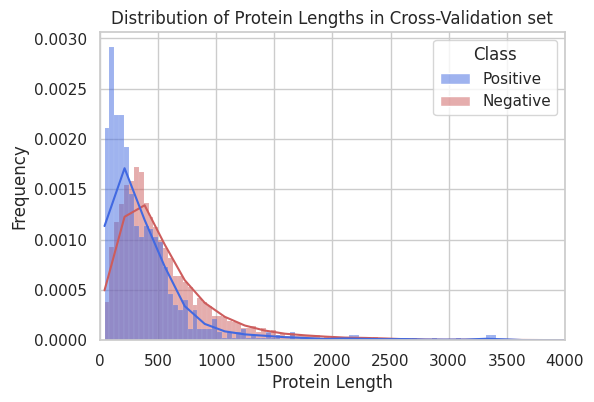

/tmp/ipykernel_6115/2688900421.py:21: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.histplot(bench_df, kde=True, x='Length', hue='Class', stat='density', common_norm=False, palette=custom_palette)


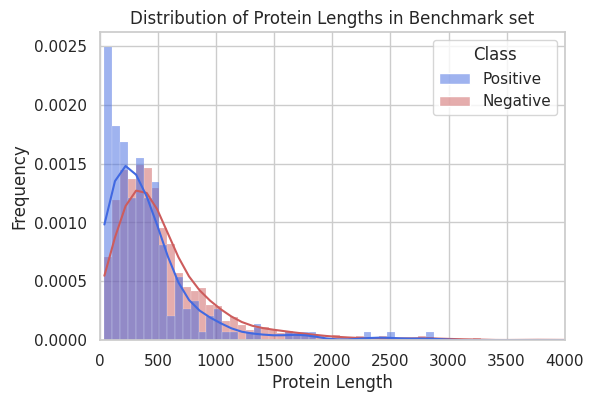

In [ ]:
# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# Plot the distribution of protein lengths
# Cross-Validation
plt.figure(figsize=(6, 4))
palette = sns.color_palette("husl",8)
sns.histplot(train_df, kde=True, x='Length', hue='Class', stat='density', common_norm=False,palette=custom_palette)

# Add title and labels
plt.title('Distribution of Protein Lengths in Cross-Validation set')
plt.xlabel('Protein Length')
plt.ylabel('Frequency')
plt.xlim(0, 4000)

# Show the plot
plt.show()

# Benchmark
plt.figure(figsize=(6, 4))
sns.histplot(bench_df, kde=True, x='Length', hue='Class', stat='density', common_norm=False, palette=custom_palette)

# Add title and labels
plt.title('Distribution of Protein Lengths in Benchmark set')
plt.xlabel('Protein Length')
plt.ylabel('Frequency')
plt.xlim(0, 4000)

# Show the plot
plt.show()

/tmp/ipykernel_6115/3176651628.py:3: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(y='Length', hue='Class', data=train_df,palette=custom_palette)


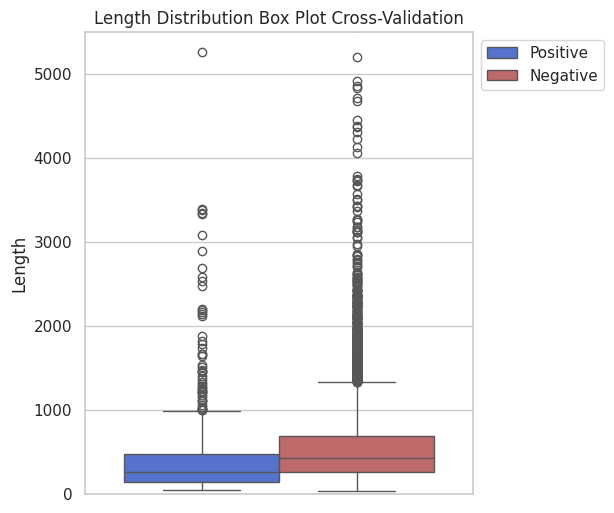

/tmp/ipykernel_6115/3176651628.py:13: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(y='Length', hue='Class', data=bench_df,palette=custom_palette)


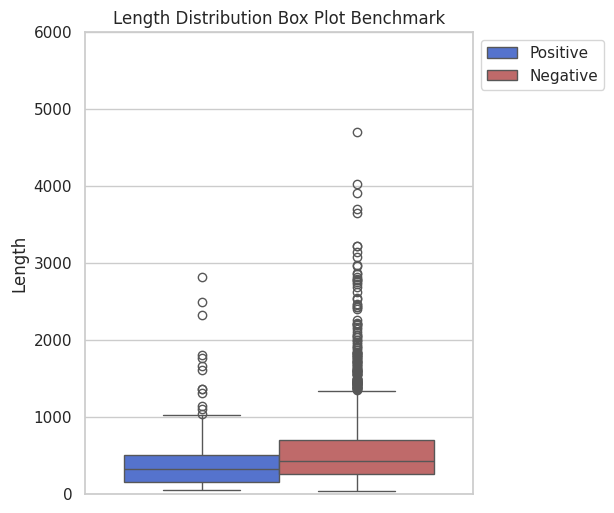

In [ ]:
#Training
plt.figure(figsize=(5, 6))
sns.boxplot(y='Length', hue='Class', data=train_df,palette=custom_palette)

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.title('Length Distribution Box Plot Cross-Validation')
plt.ylim(0, 5500)
plt.show()

#Bench
#Training
plt.figure(figsize=(5, 6))
sns.boxplot(y='Length', hue='Class', data=bench_df,palette=custom_palette)

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.title('Length Distribution Box Plot Benchmark')
plt.ylim(0, 6000)
plt.show()

No major differences between training and test are seen. Comparing the 2 distributions for positive and negative we can assume that in the positives there are proteins that are slightly shorter than in the negative set. However, that feature can't be used to discriminate the positives and the negatives, it is hard to select a treshold, and many negatives have also low values. It is slightly informative but not as much to be included in the model.

## **Distribution of SP length in the train and in the test**

In [ ]:
df_sp_l = pd.concat([pos_cv, pos_bench], axis=0)
#print(df_sp_l.head())
df_sp_l['Class']=df_sp_l['Set'].isna()
df_sp_l['Class']=df_sp_l['Class'].replace({True: 'Benchmark', False: 'Cross-Validation'})

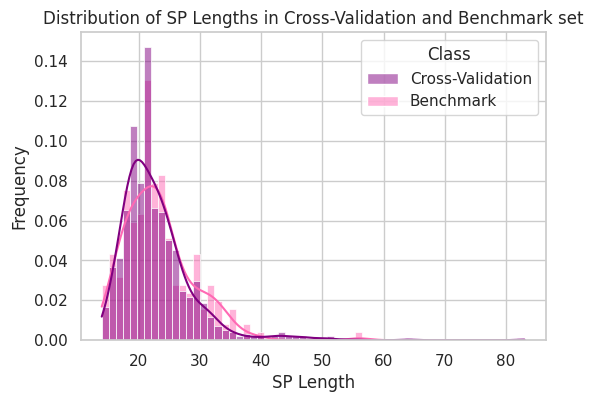

In [ ]:
# Plot the distribution of protein lengths
plt.figure(figsize=(6, 4))
sns.histplot(df_sp_l, kde=True, stat='density', common_norm=False, x='Cleavage', hue='Class', palette=custom_palette[2:])

# Add title and labels
plt.title('Distribution of SP Lengths in Cross-Validation and Benchmark set')
plt.xlabel('SP Length')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [ ]:
df_sp_l.describe()

,Length,Cleavage,Set
count,1101.000000,1101.000000,881.000000
mean,398.750227,22.952770,3.002270
std,447.997425,6.002238,1.415818
min,46.000000,14.000000,1.000000
25%,142.000000,19.000000,2.000000
50%,274.000000,22.000000,3.000000
75%,487.000000,25.000000,4.000000
max,5263.000000,83.000000,5.000000


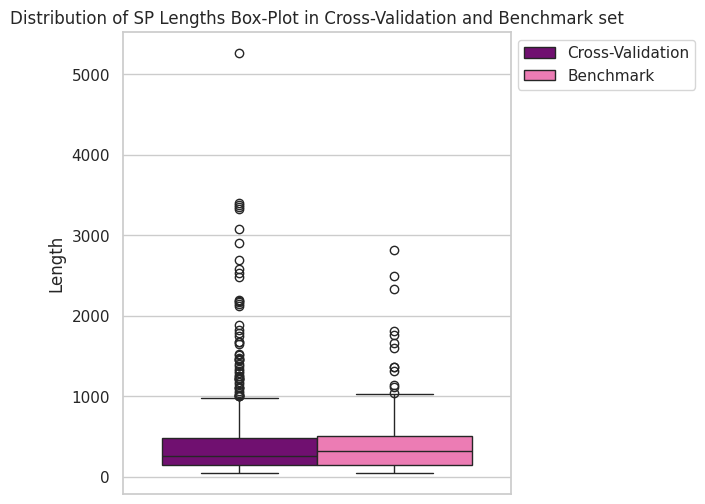

In [ ]:
plt.figure(figsize=(5, 6))
sns.boxplot(y='Length', hue='Class', data=df_sp_l, palette=custom_palette[2:])

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.title('Distribution of SP Lengths Box-Plot in Cross-Validation and Benchmark set')
plt.show()

They are quite superimposed. We can determine the average length of the SP, to understand in which region to focus (e.g. look at the first 30 residues and not at the first 100 residues)

## **Aminoacids Composition**
Relative composition of the SP in the train and the bench, compare them against each other and with the general distribution from swiss-prot that comprehends numerous reviewed proteins.

In [ ]:
df_aa = pd.DataFrame({
    'aa': ['L', 'A', 'G', 'V', 'E', 'S', 'I', 'K', 'R', 'D', 'T', 'P', 'N', 'Q', 'F', 'Y', 'M', 'H', 'C', 'W', 'X', 'U', 'B', 'Z', 'O'],
    'swiss_prot': [9.65, 8.26, 7.07, 6.85, 6.71, 6.67, 5.90, 5.80, 5.53, 5.46, 5.37, 4.75, 4.06, 3.93, 3.87, 2.92, 2.41, 2.28, 1.39, 1.11, 0.0001, 0.0, 0.0, 0.0, 0.0]
})

In [ ]:
def read_fasta_to_dict(fasta_filename):
    sequences = {}
    current_id = None
    current_seq_lines = []
    with open(fasta_filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id and current_seq_lines:
                    sequences[current_id] = ''.join(current_seq_lines)
                current_id = line[1:]
                current_seq_lines = []
            else:
                current_seq_lines.append(line)
        if current_id and current_seq_lines:
            sequences[current_id] = ''.join(current_seq_lines)
    return sequences

# Load full FASTA sequences
full_positive_fasta_sequences = read_fasta_to_dict('positive.fasta')

# Map sequences to cross-validation and benchmark
bench_map = pd.Series(pos_bench.Cleavage.values, index=pos_bench.ID).to_dict()
cv_map = pd.Series(pos_cv.Cleavage.values, index=pos_cv.ID).to_dict()

with open('cv_SP.seq', 'w') as w_cv:
    for prot_id, cleavage_site in cv_map.items():
        if prot_id in full_positive_fasta_sequences:
            full_seq = full_positive_fasta_sequences[prot_id]
            end_idx = int(cleavage_site)
            w_cv.write(full_seq[:end_idx + 1] + '\n')

with open('bench_SP.seq', 'w') as w_bench:
    for prot_id, cleavage_site in bench_map.items():
        if prot_id in full_positive_fasta_sequences:
            full_seq = full_positive_fasta_sequences[prot_id]
            end_idx = int(cleavage_site)
            w_bench.write(full_seq[:end_idx + 1] + '\n')

In [ ]:
with open('bench_SP.seq','r') as read:
  AA_bench = {}
  tot_bench = 0
  for line in read:
    for char in line.rstrip():
      if char not in AA_bench:
        AA_bench[char] = 1
      else:
        AA_bench[char] += 1
      tot_bench += 1
  read.close()

for char in AA_bench:
  AA_bench[char]=round((AA_bench[char])/tot_bench*100,2)

with open('cv_SP.seq','r') as read:
  AA_cv = {}
  tot_cv = 0
  for line in read:
    for char in line.rstrip():
      if char not in AA_cv:
        AA_cv[char] = 1
      else:
        AA_cv[char] += 1
      tot_cv += 1
  read.close()


for char in AA_cv:
  AA_cv[char]=round((AA_cv[char])/tot_cv*100,2)

In [ ]:
df_aa['Bench'] = df_aa['aa'].map(AA_bench).fillna(0)
df_aa['CV'] = df_aa['aa'].map(AA_cv).fillna(0)

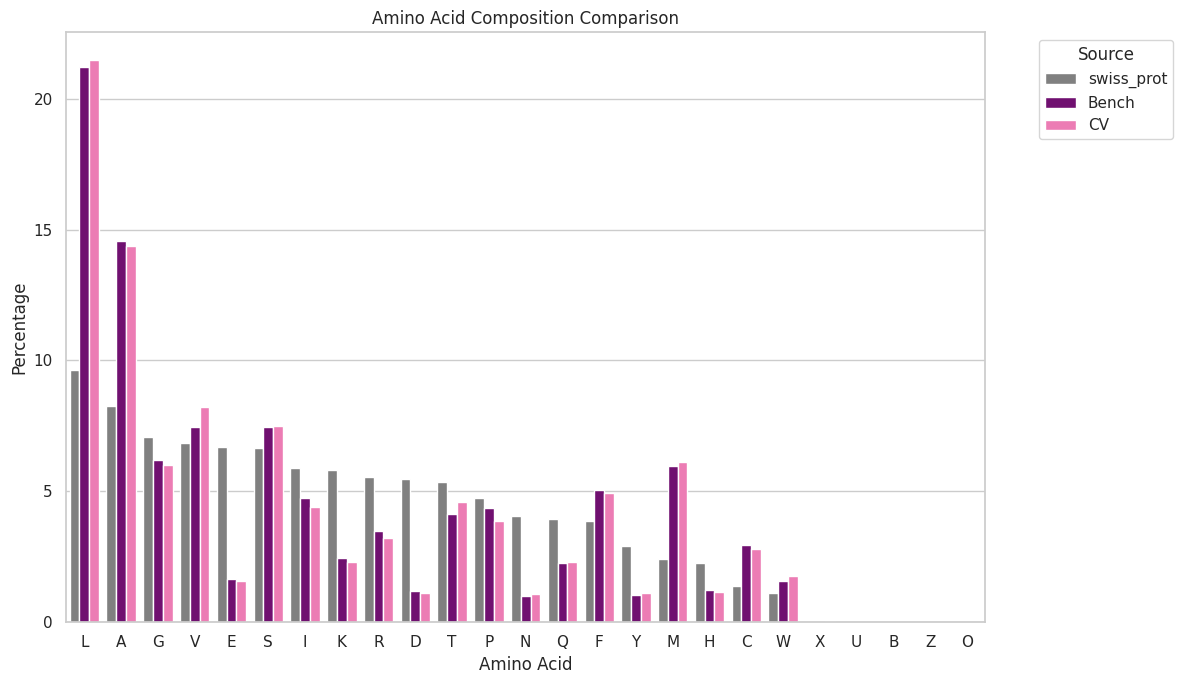

In [ ]:
df_aa_melted = df_aa.melt(id_vars=['aa'], var_name='Source', value_name='Percentage')
df_aa_melted['Percentage'] = pd.to_numeric(df_aa_melted['Percentage'])

plt.figure(figsize=(12, 7))
sns.barplot(data=df_aa_melted, x='aa', y='Percentage', hue='Source', palette={'swiss_prot': 'gray', 'Bench': custom_palette[2], 'CV': custom_palette[3]})

plt.title('Amino Acid Composition Comparison')
plt.xlabel('Amino Acid')
plt.ylabel('Percentage')
plt.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

No big differences between cross-validation and benchmark, no biases during the splitting.
Comparing train and bench with SwissProt we can see that there are aminoacids overrepresented in the SP and other that are underrepresented. This is expected because the SP has a specific internal structure and mostly composed by hydrophobic residues, while charged residues are underrepresented. The underrepresentation of charged is not so expected because the first part of the SP is charged, but only 3-4 residues and some SP that don't even have this part. For this reason, the hydrophobic residues dominates the distribution. We can include the abundance of the hydrophobic and positively charged residues as feature.

## **Taxonomic Classification**

• **Kingdom**

Different animals' sequences are present in cross-validation and benchmark. There are no major differences. The kingdom has some effect on protein length composition due to the common evolution of the SP.

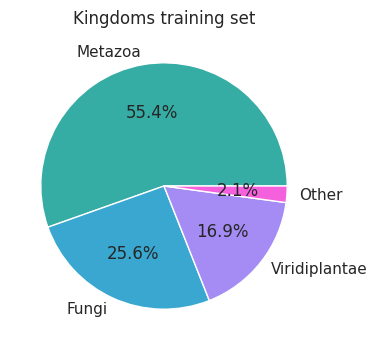

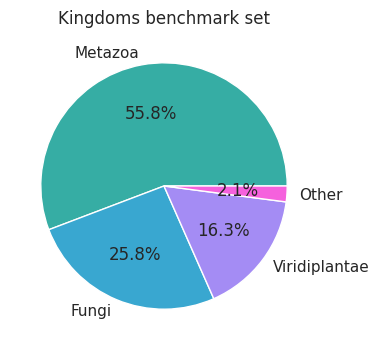

In [ ]:
king_train = train_df['Kingdom'].value_counts() #how many for each category
king_bench = bench_df['Kingdom'].value_counts()
#print(count)

# Plot a pie chart
king_train.plot.pie(autopct='%1.1f%%', figsize=(4, 4), title='Kingdoms training set',colors=palette[4:])
plt.ylabel('')
plt.show()

king_bench.plot.pie(autopct='%1.1f%%', figsize=(4, 4), title='Kingdoms benchmark set',colors=palette[4:])
plt.ylabel('')
plt.show()

• **Species**

Human are the most represented. Also in this case there are no major differences between train and test.

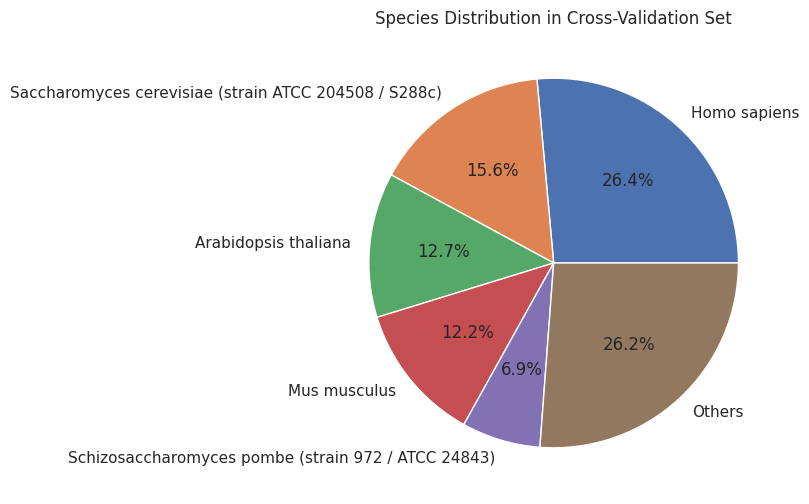

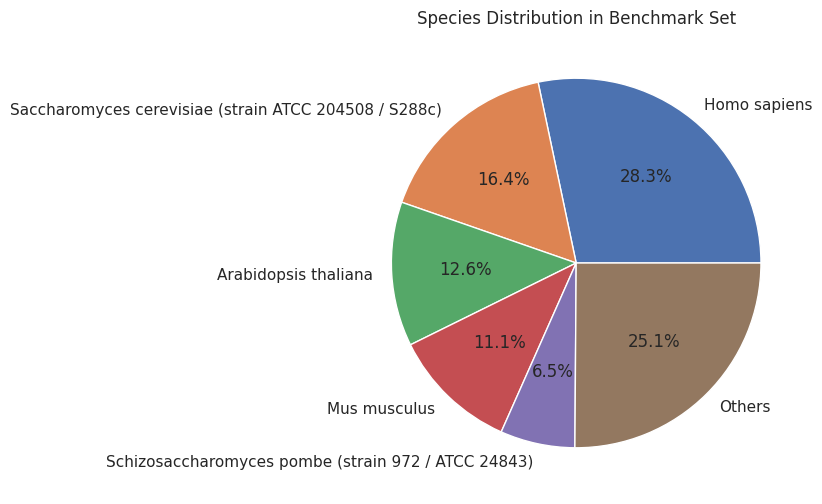

In [ ]:
species_train = train_df['Species'].value_counts()
species_bench = bench_df['Species'].value_counts()

# Calculate percentages for cv set
species_train_perc = species_train / species_train.sum() * 100

# Group species with less than 5% into 'Others' for cv set
threshold = 5
other_train = species_train_perc[species_train_perc < threshold].sum()
species_train_filtered = species_train_perc[species_train_perc >= threshold]
species_train_filtered['Others'] = other_train

# Plot the species distribution for cv set with 'Others'
species_train_filtered.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Species Distribution in Cross-Validation Set')
plt.ylabel('')  # Remove y-axis label
plt.show()

# Calculate percentages for benchmark set
species_bench_perc = species_bench / species_bench.sum() * 100

# Group species with less than 5% into 'Others' for benchmark set
other_bench = species_bench_perc[species_bench_perc < threshold].sum()
species_bench_filtered = species_bench_perc[species_bench_perc >= threshold]
species_bench_filtered['Others'] = other_bench

# Plot the species distribution for benchmark set with 'Others'
species_bench_filtered.plot.pie(autopct='%1.1f%%', figsize=(6, 6), title='Species Distribution in Benchmark Set')
plt.ylabel('')  # Remove y-axis label
plt.show()

## **Sequence Logo**
To visualize if there are some particular motifs in the signal peptide, we analyse the context of the cleavage site. We select a range of 15 residues areound the site (-13 to +2), to capture the structural transition between the signal peptide and the mature protein.

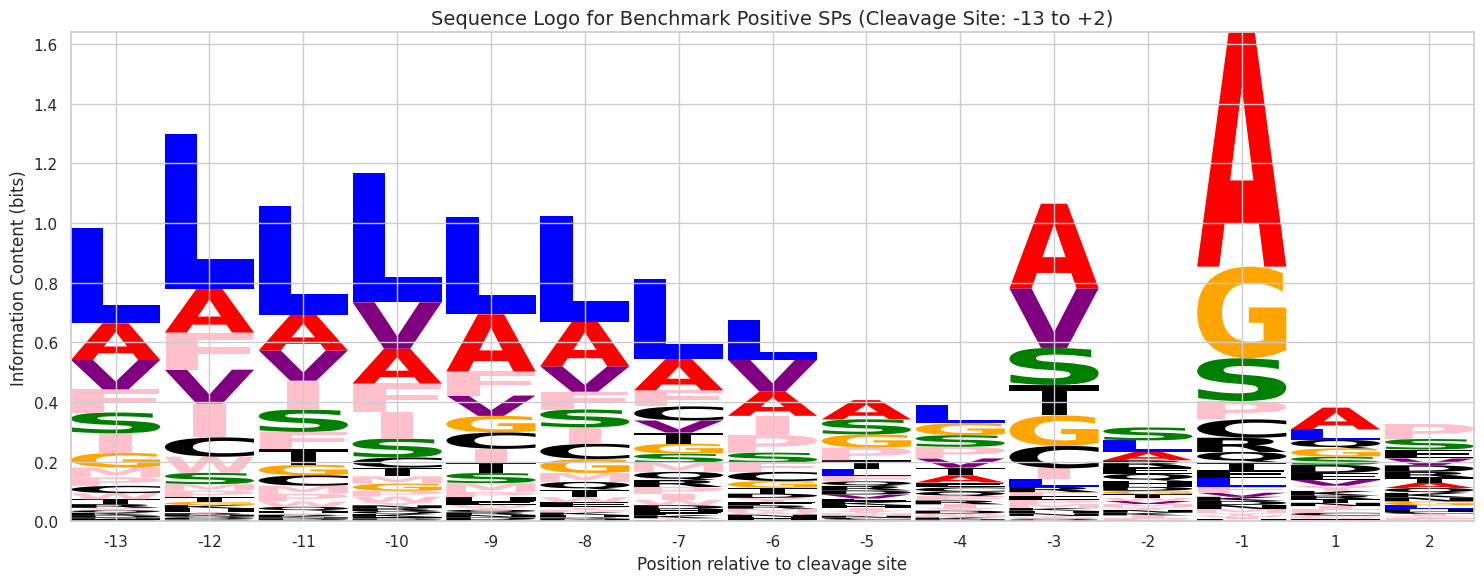

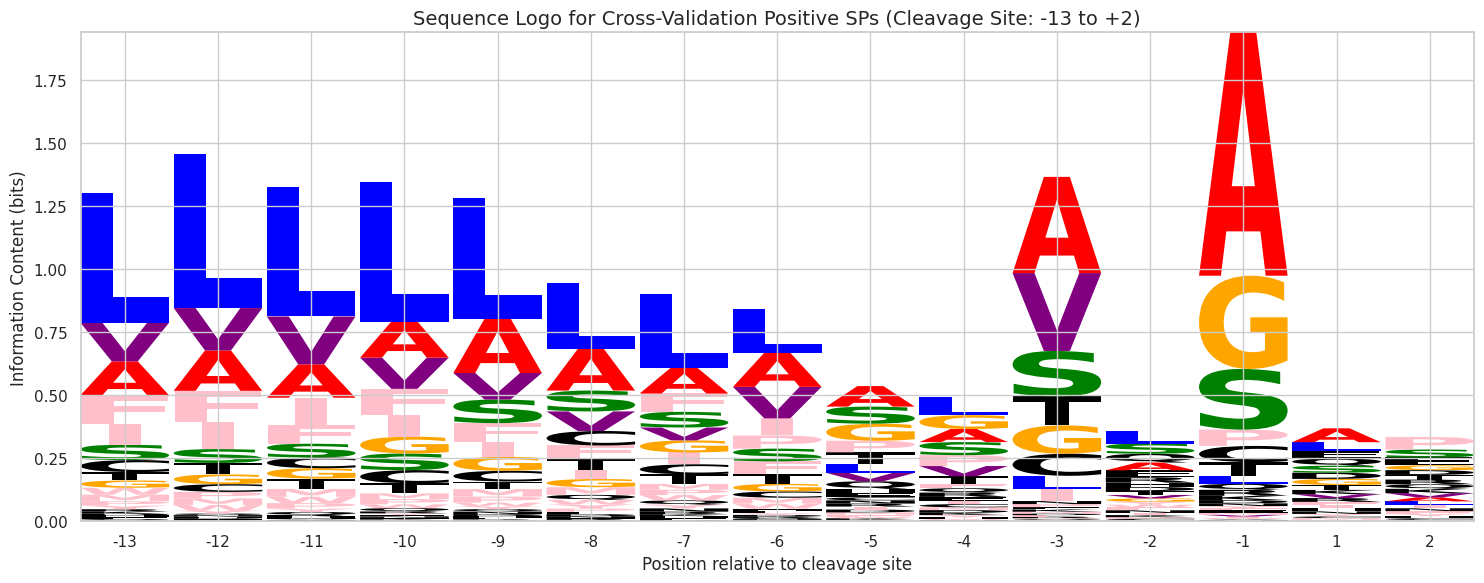

In [ ]:
def get_sequences_around_cleavage(fasta_data_dict, df_positive, upstream_offset=13, downstream_offset=2):
    extracted_sequences = []
    expected_window_length = upstream_offset + downstream_offset

    for index, row in df_positive.iterrows():
        protein_id = row['ID']
        cleavage_site_1idx = row['Cleavage']

        if protein_id in fasta_data_dict:
            full_seq = fasta_data_dict[protein_id]
            slice_start_0idx = cleavage_site_1idx - upstream_offset
            slice_end_0idx_exclusive = cleavage_site_1idx + downstream_offset

            segment_chars = []
            for i in range(slice_start_0idx, slice_end_0idx_exclusive):
                if 0 <= i < len(full_seq):
                    segment_chars.append(full_seq[i])
                else:
                    segment_chars.append('X')

            if len(segment_chars) == expected_window_length:
                extracted_sequences.append(''.join(segment_chars))

    return extracted_sequences

# Extract cleavage windows
bench_cleavage_sequences = get_sequences_around_cleavage(full_positive_fasta_sequences, pos_bench, upstream_offset=13, downstream_offset=2)
cv_cleavage_sequences = get_sequences_around_cleavage(full_positive_fasta_sequences, pos_cv, upstream_offset=13, downstream_offset=2)

# Generate raw count matrices
bench_counts_df_cleavage = lm.alignment_to_matrix(sequences=bench_cleavage_sequences, to_type='counts', pseudocount=0)
cv_counts_df_cleavage = lm.alignment_to_matrix(sequences=cv_cleavage_sequences, to_type='counts', pseudocount=0)

# Convert counts to bits
bench_info_df = lm.transform_matrix(bench_counts_df_cleavage, from_type='counts', to_type='information')
cv_info_df = lm.transform_matrix(cv_counts_df_cleavage, from_type='counts', to_type='information')

# Define custom color mapping by chemical properties and most frequent aa
color_map = {
    'D': 'black', 'E': 'black', 'K': 'black', 'R': 'black',
    'T': 'black', 'C': 'black', 'N': 'black', 'Q': 'black', 'H': 'black',
    'S': 'green',
    'F': 'pink', 'W': 'pink', 'Y': 'pink',
    'V': 'purple',
    'G': 'orange',
    'A': 'red',
    'L': 'blue',
    'P': 'pink', 'I': 'pink', 'M': 'pink',
    'X': 'gray'
}

x_labels = [str(i) for i in range(-13, 0)] + [str(i) for i in range(1, 3)]

# Plot Benchmark Sequence Logo
fig1, ax1 = plt.subplots(figsize=(15, 6))
logo_bench_cleavage = lm.Logo(bench_info_df, color_scheme=color_map, ax=ax1)
logo_bench_cleavage.ax.set_title('Sequence Logo for Benchmark Positive SPs (Cleavage Site: -13 to +2)', fontsize=14)
logo_bench_cleavage.ax.set_xlabel('Position relative to cleavage site', fontsize=12)
logo_bench_cleavage.ax.set_ylabel('Information Content (bits)', fontsize=12)
logo_bench_cleavage.ax.set_xticks(range(bench_info_df.shape[0]))
logo_bench_cleavage.ax.set_xticklabels(x_labels)
plt.tight_layout()
plt.show()

# Plot Cross-Validation Sequence Logo
fig2, ax2 = plt.subplots(figsize=(15, 6))
logo_cv_cleavage = lm.Logo(cv_info_df, color_scheme=color_map, ax=ax2)
logo_cv_cleavage.ax.set_title('Sequence Logo for Cross-Validation Positive SPs (Cleavage Site: -13 to +2)', fontsize=14)
logo_cv_cleavage.ax.set_xlabel('Position relative to cleavage site', fontsize=12)
logo_cv_cleavage.ax.set_ylabel('Information Content (bits)', fontsize=12)
logo_cv_cleavage.ax.set_xticks(range(cv_info_df.shape[0]))
logo_cv_cleavage.ax.set_xticklabels(x_labels)
plt.tight_layout()
plt.show()

Leucine and hydrophobic residues are very frequent in the first part of the plot, capturing the functional core of the SP.
Around the cleavage there is a specific motif A_A, which represents a possible recognition site. However, this can't be used as a real feature because this motif alone is too shot and it's common to be found in a protein.
The trend is consistent between cross-validation and benchmark sets.

# **5. vonHeijne Method**
The vonHeijne method compares the composition of the region analyzed
during the logo generation against a reference background distribution,
in order to define a position-specific weight matrix. This allows to iden-
tify the important residues in the detection of the specific motives in
proximity of the cleavage site of the signal peptide.

In [ ]:
import pandas as pd
import numpy as np

import sklearn as skl
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_recall_curve
import sklearn.metrics

import seaborn as sns
import matplotlib.pyplot as plt

## **Cross-Validation**

In [ ]:
# Specify the column names
col_pos_train = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage', 'Set']
col_neg_train = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane', 'Set']

# Load the TSV file into a DataFrame
pos_train = pd.read_csv('cv_pos.tsv', sep='\t', header=None, names=col_pos_train)
neg_train = pd.read_csv('cv_neg.tsv', sep='\t', header=None, names=col_neg_train)

# Display the first few rows of the DataFrame
# print(pos_train.head())
# print(neg_train.head())

Extracts specific sequence features, labels, and partition sets from the FASTA files to format the training inputs for the von Heijne model (saved as .tsv).
* **Positives:** Includes the -13 to +2 residues around the cleavage site and a positive label (1).
* **Negatives:** Includes the N-terminal sequence and a negative label (0).

In [ ]:
# Create a customize file for the Positives
with open('positive.fasta', 'r') as read:
  with open('vonHeijne_pos_train.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = pos_train.query("ID == @line")
        if not query['Cleavage'].empty:
          end = int(query['Cleavage'].iloc[0])
          line = read.readline()
          print(query['ID'].iloc[0]+'\t'+line[end-13:end+2]+'\t'+str(query['Set'].iloc[0])+'\t1\t'+line.rstrip()[:90], file=write)

#Create a customize file for the Negatives
with open('negative.fasta', 'r') as read:
  with open('vonHeijne_neg_train.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = neg_train.query("ID == @line")
        if not query.empty:
          line = read.readline()
          print(query['ID'].iloc[0]+'\t'+str(query['Set'].iloc[0])+'\t0\t'+line.rstrip()[:90], file=write)

In [ ]:
# Read the new files and concatenate them in a unique dataframe
col_pos = ['ID', 'SP', 'Set', 'Class', 'Sequence']
col_neg = ['ID', 'Set', 'Class', 'Sequence']

pos = pd.read_csv('vonHeijne_pos_train.tsv', sep='\t', header=None, names=col_pos)
neg = pd.read_csv('vonHeijne_neg_train.tsv', sep='\t', header=None, names=col_neg)

vonHeijne_df = pd.concat([pos, neg], axis=0)

# Display the first lines of the dataframe
#print(vonHeijne_df.head())

In [ ]:
# Background probabilities from swiss-prot
df_aa = pd.DataFrame({
    'aa': ['G', 'A', 'V', 'P', 'L', 'I', 'M', 'F', 'W', 'Y', 'S', 'T', 'C', 'N', 'Q', 'H', 'D', 'E', 'K', 'R', 'X'],
    'swiss_prot': [7.07, 8.26, 6.85, 4.75, 9.65, 5.90, 2.41, 3.87, 1.11, 2.92,  6.67, 5.37, 1.39, 4.06, 3.93, 2.28, 5.46, 6.71, 5.80, 5.53, 0.01]
})

alphabet = df_aa['aa'].tolist()

aa_bg = df_aa['swiss_prot'] / 100.0

# Initialise a Matrix
f_matrix = np.ones((15,21))
#print(f_matrix)

In [ ]:
# Define the sets to do the 5-fold Cross Validation
# Train, Validation, Test
folds = [1, 2, 3, 4, 5]
cycles = [([f for f in folds if f != folds[i] and f != folds[i-1]], [folds[i-1]], [folds[i]]) for i in range(5)]
print(cycles)

[([2, 3, 4], [5], [1]), ([3, 4, 5], [1], [2]), ([1, 4, 5], [2], [3]), ([1, 2, 5], [3], [4]), ([1, 2, 3], [4], [5])]


In [ ]:
# Encoding
def encoding(sequence, alphabet):
  # Initialize the OneHotEncoder
  encoder = OneHotEncoder(categories=[alphabet], sparse_output=False)
  # Reshape the sequence to match the expected input format (n_samples, n_features)
  sequences = np.array(list(sequence)).reshape(-1, 1)
  # Fit and transform the sequence to one-hot encoding
  one_hot_encoded = encoder.fit_transform(sequences)
  return one_hot_encoded

In [ ]:
def score_pattern(matrix, alphabet, fragment):
  score =  0
  for i in range(len(fragment)):
    char = fragment[i]
    if char == 'U':
      char = 'C'
    score += matrix[i][alphabet.index(char)]
  return score

# Maximum Score
def score_sequence(matrix,alphabet,sequence):
  max = None
  length = len(sequence)
  for i in range(0,length-14):
    score = score_pattern(matrix,alphabet,sequence[i:i+15])
    if (max==None) or (score>max):
      max = score
  return max

In [ ]:
av_th =0
av_accuracy = []
av_sensitivity = []
av_ppv = []
av_mcc = []
av_f1 =[]

for cycle in cycles:
  #1. TRAIN
  #Initialize a matrix with same shape of one-hot encoded matrix
  f_matrix = np.ones((15,21)) #1 in every cell
  #print(f_matrix)
  #Create a dataframe for Training
  df_train = vonHeijne_df[(vonHeijne_df['Class']==1) & (vonHeijne_df['Set'].isin(cycle[0]))]
  total_seq = df_train.shape[0]+20
  #count = 0
  for index, row in df_train.iterrows():
    f_matrix = f_matrix + encoding(row['SP'], alphabet)
    #count += 1
  # Divide by the number of sequences and for the frequency in SwissProt (BackGround)
  f_matrix=np.log2((f_matrix/total_seq)/aa_bg.values)

  #print(f_matrix)

  #2. VALIDATION --> optimize the hyperparameter: threshold
  #Create a dataframe for Validation
  df_val = vonHeijne_df[vonHeijne_df['Set'].isin(cycle[1])]
  y_val = df_val['Class'].to_numpy()
  #print(y_val)
  y_val_scores = []
  for index,row in df_val.iterrows():
    y_val_scores.append(score_sequence(f_matrix,alphabet,row['Sequence']))

  precision, recall, thresholds = precision_recall_curve(y_val, y_val_scores)
  # Compute f-scores at varying thresholds
  fscore = (2 * precision * recall) / (precision + recall)
  # Get the index of the maximum value of the f-score
  index = np.argmax(fscore)
  # Retrieve the threshold value corresponding to the max f-score computed above
  optimal_threshold = thresholds[index]
  av_th += optimal_threshold

  #3. TEST
  #Create a dataframe for Test
  df_test = vonHeijne_df[vonHeijne_df['Set'].isin(cycle[2])]
  y_test = df_test['Class'].to_numpy()
  # SP detection scores assigned to each testing example by means of weight matrix scanning
  y_test_scores = []

  for index,row in df_test.iterrows():
    y_test_scores.append(score_sequence(f_matrix,alphabet,row['Sequence']))

  # Classify examples in the testing set
  y_pred_test = [int(t_s >= optimal_threshold) for t_s in y_test_scores]
  cm = sklearn.metrics.confusion_matrix(y_test, y_pred_test)
  #print(cm)
  TN, FP, FN, TP = cm.ravel()

  # Save the Outputs in a file
  with open('vonheijne_res_cv.txt', 'a') as write:
    print("Optimal Threshold: "+str(optimal_threshold)+"\n",file=write)
    print("Confusion Matrix:\n"+str(cm)+"\n",file=write)
    print("TN:"+str(TN)+", FP:"+str(FP)+", FN:"+str(FN)+", TP:"+str(TP)+"\n",file=write)

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    mcc = ((TP * TN) - (FP * FN)) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) if (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) > 0 else 0
    f1 = (2 * ppv * sensitivity) / (sensitivity + ppv)

    av_accuracy.append(accuracy)
    av_sensitivity.append(sensitivity)
    av_ppv.append(ppv)
    av_mcc.append(mcc)
    av_f1.append(f1)

    # Print metrics
    print(f"Accuracy: {accuracy:.4f}"+f", Sensitivity:{sensitivity:.4f}"+f", PPV: {ppv:.4f}"+f", MCC: {mcc:.4f}"+f", F1 Score: {f1:.4f}\n",file=write)

In [ ]:
# Save Average Threshold, Accuracy, Sensitivity, PPV and MMC
with open('vonheijne_res_cv.txt', 'a') as write:
  print(f'Average Threshold: {av_th/5:.4f}',file=write)
  print(f'Average Accuracy: {np.mean(av_accuracy):.4f} ± {np.std(av_accuracy/np.sqrt(len(av_accuracy))):.4f}',file=write)
  print(f'Average Sensitivity: {np.mean(av_sensitivity):.4f} ± {np.std(av_sensitivity/np.sqrt(len(av_sensitivity))):.4f}',file=write)
  print(f'Average PPV: {np.mean(av_ppv):.4f} ± {np.std(av_ppv/np.sqrt(len(av_ppv))):.4f}',file=write)
  print(f'Average MCC: {np.mean(av_mcc):.4f} ± {np.std(av_mcc/np.sqrt(len(av_mcc))):.4f}',file=write)
  print(f'Average F1 Score: {np.mean(av_f1):.4f} ± {np.std(av_f1/np.sqrt(len(av_f1))):.4f} \n',file=write)

In [ ]:
# FINAL TRAINING
# Matrix with same shape as one-hot encoded matrix
final_matrix = np.ones((15, 21))

# Create a dataframe for Training
df_train = vonHeijne_df[(vonHeijne_df['Class']==1)]
total_seq = df_train.shape[0]+20
#count = 0
for index, row in df_train.iterrows():
  final_matrix = final_matrix + encoding(row['SP'], alphabet)
  #count +=1

final_matrix = np.log2((final_matrix/total_seq)/aa_bg.values)

# Save the final Output
with open('vonheijne_final_res_cv.txt', 'a') as write:
  print('Final Matrix:\n'+str(final_matrix),file=write)
  write.close

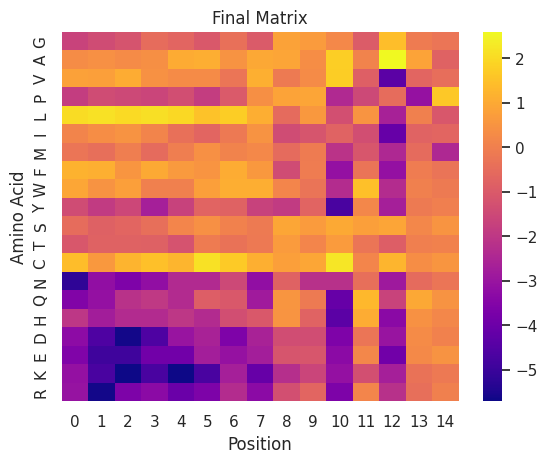

In [ ]:
# Create a heatmap
sns.heatmap(final_matrix.T[:-1], cmap='plasma', annot=False, fmt='.2f', yticklabels=alphabet[:-1])

# Set labels
plt.xlabel('Position')
plt.ylabel('Amino Acid')

# Set the title
plt.title('Final Matrix')

# Show the plot
plt.show()

## **Final Testing**

In [ ]:
# Specify the column names
col_pos_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage']
col_neg_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane']

# Load the TSV file into a DataFrame
pos_bench = pd.read_csv('bench_pos.tsv', sep='\t', header=None, names=col_pos_bench)
neg_bench = pd.read_csv('bench_neg.tsv', sep='\t', header=None, names=col_neg_bench)

# Display the first few rows of the DataFrame
# print(pos_bench.head())
# print(neg_bench.head())

In [ ]:
# Create a customize file for the Positives
with open('positive.fasta', 'r') as read:
  with open('vonHeijne_pos_bench.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = pos_bench.query("ID == @line")
        if not query.empty:
          line = read.readline()
          print(query['ID'].iloc[0]+'\t1\t'+line.rstrip()[:90], file=write)

# Create a customize file for the Negatives
with open('negative.fasta', 'r') as read:
  with open('vonHeijne_neg_bench.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = neg_bench.query("ID == @line")
        if not query.empty:
          line = read.readline()
          print(query['ID'].iloc[0]+'\t0\t'+line.rstrip()[:90], file=write)

In [ ]:
# Read the new files and concatenate them in a unique dataframe
col_test = ['ID', 'Class', 'Sequence']

pos_test = pd.read_csv('vonHeijne_pos_bench.tsv', sep='\t', header=None, names=col_test)
neg_test = pd.read_csv('vonHeijne_neg_bench.tsv', sep='\t', header=None, names=col_test)

test_df = pd.concat([pos_test, neg_test], axis=0)

# Display the first lines of the dataframe
#print(test_df.head())

In [ ]:
y_test = test_df['Class'].to_numpy()
# SP detection scores assigned to each testing example by means of weight matrix scanning
y_test_scores = []

for index,row in test_df.iterrows():
  y_test_scores.append(score_sequence(final_matrix,alphabet,row['Sequence']))

# Classify examples in the testing set
y_pred_test = [int(t_s >= (av_th/5)) for t_s in y_test_scores]
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_test)
#print(cm)
TN, FP, FN, TP = cm.ravel()

# Save the Outputs in a file
with open('vonheijne_bench_res.txt', 'w') as write:
  print('The used threshold is: '+str(av_th/5), file=write)
  print("Confusion Matrix:\n"+str(cm),file=write)
  print("TN:"+str(TN)+", FP:"+str(FP)+", FN:"+str(FN)+", TP:"+str(TP),file=write)

  accuracy = (TP + TN) / (TP + TN + FP + FN)
  sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
  ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
  mcc = ((TP * TN) - (FP * FN)) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) if (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) > 0 else 0
  f1 = (2 * ppv * sensitivity) / (sensitivity + ppv)

  # Print metrics
  print(f"Accuracy: {accuracy:.4f}"+f", Sensitivity:{sensitivity:.4f}"+f", PPV: {ppv:.4f}"+f", MCC: {mcc:.4f}"+f", F1 Score: {f1:.4f}\n",file=write)

In [ ]:
# Add 'Prediction' column to the test dataframe
test_df['Prediction'] = y_pred_test
print(test_df.shape)
print(test_df.head())

(2035, 4)
       ID  Class                                           Sequence  \
0  O43155      1  MGLQTTKWPSHGAFFLKSWLIISLGLYSQVSKLLACPSVCRCDRNF...   
1  O43866      1  MALLFSLILAICTRPGFLASPSGVRLVGGLHRCEGRVEVEQKGQWG...   
2  P01579      1  MKYTSYILAFQLCIVLGSLGCYCQDPYVKEAENLKKYFNAGHSDVA...   
3  P04275      1  MIPARFAGVLLALALILPGTLCAEGTRGRSSTARCSLFGSDFVNTF...   
4  P13686      1  MDMWTALLILQALLLPSLADGATPALRFVAVGDWGGVPNAPFHTAR...   

   Prediction  
0           0  
1           0  
2           1  
3           1  
4           1  


In [ ]:
#Merge the original pos and bench file to have all the metadata in one file
bench = pd.concat([pos_bench, neg_bench], axis=0)
print(bench.shape)
print(bench.head())
print(bench.tail())

(2035, 6)
       ID                                            Species  Kingdom  Length  \
0  P13727                                       Homo sapiens  Metazoa     222   
1  P43497  Saccharomyces cerevisiae (strain ATCC 204508 /...    Fungi      92   
2  P51654                                       Homo sapiens  Metazoa     580   
3  Q9NTU7                                       Homo sapiens  Metazoa     201   
4  P00651    Aspergillus oryzae (strain ATCC 42149 / RIB 40)    Fungi     130   

   Cleavage Transmembrane  
0      16.0           NaN  
1      20.0           NaN  
2      24.0           NaN  
3      27.0           NaN  
4      26.0           NaN  
          ID                                            Species  \
1810  Q8SSG3            Encephalitozoon cuniculi (strain GB-M1)   
1811  P57743  Saccharomyces cerevisiae (strain ATCC 204508 /...   
1812  Q9M7N6                               Solanum lycopersicum   
1813  Q9Y6N9                                       Homo sapiens   


In [ ]:
#Merge the original and the test set by the ID colum
final_df = pd.merge(bench, test_df, on='ID', how='outer')
#print(final_df.shape)
#print(final_df.head())

In [ ]:
#Convert the dataframe in a TSV
final_df.to_csv('vonHeijne_final.tsv', sep='\t', index=False)

# **6. Support Vector Machines: Hand-Craft encoding**
**Feature Extraction**:
* AA composition feature computed over the first 22 residues
* Other features computed over the first 40 residues:
  * Hydrophobicity using Kyte-Dolittle Scale
  * Charge Features
  * Alpha-helix propensity with Chou&Fasman scale
  * Transmembrane propensity with Zhao&London scale


In [ ]:
import pandas as pd
import numpy as np
import ast

!pip install biopython
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData

import itertools
import pickle, gzip
from collections import Counter
from sklearn import svm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef, precision_score, recall_score, f1_score

## **Feature Extraction**

In [ ]:
# Amino Acids alphabet
alphabet=list("GAVPLIMFWYSTCNQHDEKRX")

# Aminoacid Composition
def extract_ac(sequence, alphabet):
    subseq = sequence[:23].upper()
    total_len = len(subseq)

    if total_len == 0:
        return '\t'.join(["0.000"] * len(alphabet))

    counts = Counter(subseq)
    composition_list = [counts[aa] / total_len for aa in alphabet]

    return '\t'.join(f"{p:.3f}" for p in composition_list)

# Hydrophobicity
def extract_hp(sequence):
  window_size = 5
  d = int(window_size/2) #padding size
  sequence_with_padding = "-"*d + sequence + "-"*d # Use - character for padding, a character which is not a residue to get a 0 value
  # Perform the analysis using the padding sequence
  analysed_seq_padding = ProteinAnalysis(sequence_with_padding)
  kd_pos_with_padding = analysed_seq_padding.protein_scale(ProtParamData.kd, window_size)
  return (max(kd_pos_with_padding), np.mean(kd_pos_with_padding))

# Charge
def extract_ch(sequence):
  ch_scale = {'A':0, 'R':1, 'N':0, 'D':0, 'C':0, 'Q':0, 'E':0, 'G':0, 'H':1, 'I':0, 'L':0, 'K':1, 'M':0, 'F':0, 'P':0, 'S':0, 'T':0, 'W':0, 'Y':0, 'V':0, 'X':0}
  window_size=3
  d = int(window_size/2) #padding size
  sequence_with_padding = "-"*d + sequence + "-"*d # Use - character for padding, a character which is not a residue to get a 0 value
  # Perform the analysis using the padding sequence
  analysed_seq_padding = ProteinAnalysis(sequence_with_padding)
  ch_values = analysed_seq_padding.protein_scale(ch_scale, window_size)
  max = np.max(ch_values)
  norm = 1-((ch_values.index(max)+1)/len(sequence))
  return max,norm

def extract_ah(sequence):
  ah_scale = {'A': 1.420, 'R': 0.980, 'N': 0.670, 'D': 1.010, 'C': 0.700, 'Q': 1.110, 'E': 1.510, 'G': 0.570, 'H': 1.000, 'I': 1.080, 'L': 1.210, 'K': 1.160, 'M': 1.450, 'F': 1.130, 'P': 0.570, 'S': 0.770, 'T': 0.830, 'W': 1.080, 'Y': 0.690, 'V': 1.060}
  window_size = 7
  d = int(window_size/2) #padding size
  sequence_with_padding = "-"*d + sequence + "-"*d # Use - character for padding, a character which is not a residue to get a 0 value
  # Perform the analysis using the padding sequence
  analysed_seq = ProteinAnalysis(sequence_with_padding)
  ah_values = analysed_seq.protein_scale(ah_scale, window_size)
  max = np.max(ah_values)
  average = np.mean(ah_values)
  return max, average

def extract_tm(sequence):
  tm_scale = {'A': 0.380, 'R': -2.570, 'N': -1.620, 'D': -3.270, 'C': -0.300, 'Q': -1.840, 'E': -2.900, 'G': -0.190, 'H': -1.440, 'I': 1.970, 'L': 1.820, 'K': -3.460, 'M': 1.400, 'F': 1.980, 'P': -1.440, 'S': -0.530, 'T': -0.320, 'W': 1.530, 'Y': 0.490, 'V': 1.460}
  window_size = 7
  d = int(window_size/2) #padding size
  sequence_with_padding = "-"*d + sequence + "-"*d # Use - character for padding, a character which is not a residue to get a 0 value
  # Perform the analysis using the padding sequence
  analysed_seq = ProteinAnalysis(sequence_with_padding)
  tm_values = analysed_seq.protein_scale(tm_scale, window_size)
  max = np.max(tm_values)
  average = np.mean(tm_values)
  return max, average

def extract_features(sequence,alphabet):
  # Aminoacid Composition
  ac=extract_ac(sequence,alphabet)
  # Hydrophobicity
  hp_max, hp_av = extract_hp(sequence)
  # Charge
  ch_max, ch_pos = extract_ch(sequence)
  # Alpha-Helix
  ah_max, ah_av = extract_ah(sequence)
  # Transmembrane
  tm_max, tm_av= extract_tm(sequence)
  return f'{ac}\t{hp_max}\t{hp_av}\t{ah_max}\t{ah_av}\t{tm_max}\t{tm_av}\t{ch_max}\t{ch_pos}'

In [ ]:
# Specify the column names
col_pos_train = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage', 'Set']
col_neg_train = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane', 'Set']
# Load the TSV file into a DataFrame

# Load the TSV file into a DataFrame
pos_train = pd.read_csv('cv_pos.tsv', sep='\t', header=None, names=col_pos_train)
neg_train = pd.read_csv('cv_neg.tsv', sep='\t', header=None, names=col_neg_train)

# Display the first few rows of the DataFrame
# print(pos_train.head())
# print(neg_train.head())

In [ ]:
#Create a customize file for the Positives
with open('positive.fasta', 'r') as read:
  with open('svm_pos_train.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = pos_train.query("ID == @line")
        if not query['Cleavage'].empty:
          line = read.readline()
          features = extract_features(line.rstrip()[:40], alphabet)
          print(query['ID'].iloc[0]+'\t'+str(query['Set'].iloc[0])+'\t1\t'+line.rstrip()[:40]+'\t'+features, file=write)

#Create a customize file for the Negatives
with open('negative.fasta', 'r') as read:
  with open('svm_neg_train.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = neg_train.query("ID == @line")
        if not query.empty:
          line = read.readline()
          features = extract_features(line.rstrip()[:40], alphabet)
          print(query['ID'].iloc[0]+'\t'+str(query['Set'].iloc[0])+'\t0\t'+line.rstrip()[:40]+'\t'+features, file=write)

Output streaming troncato alle ultime 5000 righe.


In [ ]:
# Create a Customize Dataframe for the Benchmark

# Specify the column names
col_pos_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage']
col_neg_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane']

# Load the TSV file into a DataFrame
pos_bench = pd.read_csv('bench_pos.tsv', sep='\t', header=None, names=col_pos_bench)
neg_bench = pd.read_csv('bench_neg.tsv', sep='\t', header=None, names=col_neg_bench)

In [ ]:
#Create a customize file for the positives
with open('positive.fasta', 'r') as read:
  with open('svm_bench_pos.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = pos_bench.query("ID == @line")
        if not query.empty:
          line = read.readline()
          features = extract_features(line.rstrip()[:40], alphabet)
          print(query['ID'].iloc[0]+'\t1\t'+line.rstrip()[:40]+'\t'+features, file=write)

#Create a customize file for the negatives
with open('negative.fasta', 'r') as read:
  with open('svm_bench_neg.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = neg_bench.query("ID == @line")
        if not query.empty:
          line = read.readline()
          features = extract_features(line.rstrip()[:40], alphabet)
          print(query['ID'].iloc[0]+'\t0\t'+line.rstrip()[:40]+'\t'+features, file=write)

Output streaming troncato alle ultime 5000 righe.


## **Cross-Validation and Grid Search**
Test all the diﬀerent combinations of input features.
Calculate the performance for every combination.
Test differrent C and gamma parameters. Use RBF Kernel.

In [ ]:
#Read the training files and concatenate them in a unique dataframe
col = ['ID','Set','Class','Sequence','G','A','V','P','L','I','M','F','W','Y','S','T','C','N','Q','H','D','E','K','R','X','hp_max','hp_mean','ah_max','ah_mean','tm_max','tm_mean','ch_max','ch_pos']

pos = pd.read_csv('svm_pos_train.tsv', sep='\t', header=None, names=col)
neg = pd.read_csv('svm_neg_train.tsv', sep='\t', header=None, names=col)

svm_df = pd.concat([pos, neg], axis=0)
print(svm_df.head())

       ID  Set  Class                                  Sequence      G      A  \
0  O75629    5      1  MAGLSRGSARALLAALLASTLLALLVSPARGRGGRDHGDW  0.087  0.304   
1  O94985    2      1  MLRRPAPALAPAARLLLAGLLCGGGVWAARVNKHKPWLEP  0.087  0.261   
2  P02649    5      1  MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQS  0.043  0.217   
3  P02743    2      1  MNKPLLWISVLTSLLEAFAHTDLSGKVFVFPRESVTDHVN  0.000  0.087   
4  P02774    4      1  MKRVLVLLLAVAFGHALERGRDYEKNKVCKEFSHLGKEDF  0.087  0.130   

       V      P      L      I  ...      R    X  hp_max  hp_mean    ah_max  \
0  0.000  0.000  0.304  0.000  ...  0.087  0.0    3.48   0.3380  1.300000   
1  0.000  0.130  0.304  0.000  ...  0.130  0.0    2.56   0.2795  1.267143   
2  0.130  0.000  0.174  0.000  ...  0.000  0.0    3.08  -0.1325  1.278571   
3  0.043  0.043  0.261  0.043  ...  0.000  0.0    2.48   0.3875  1.271429   
4  0.130  0.000  0.217  0.000  ...  0.130  0.0    3.96  -0.1695  1.237143   

    ah_mean    tm_max   tm_mean    ch_max  ch_pos 

In [ ]:
print(svm_df.shape)

(8142, 33)


In [ ]:
# Define the sets to do the 5-fold Cross Validation
# Train, Validation, Test
folds = [1, 2, 3, 4, 5]
cycles = [([f for f in folds if f != folds[i] and f != folds[i-1]], [folds[i-1]], [folds[i]]) for i in range(5)]
print(cycles)

# C and gamma parameters
Cs = [0.1, 1, 2, 4, 8]
gammas = [0.001, 0.01, 0.1, 1, 'scale']

[([2, 3, 4], [5], [1]), ([3, 4, 5], [1], [2]), ([1, 4, 5], [2], [3]), ([1, 2, 5], [3], [4]), ([1, 2, 3], [4], [5])]


In [ ]:
# Generate all the possible combinations + aminoacid composition (which is always considered)
elements = ['hp', 'ah', 'tm', 'ch']
models = [list(c) + ['ac'] for r in range(1, len(elements) + 1) for c in itertools.combinations(elements, r)]
models.append(['ac'])

print(models)
print(len(models))

[['hp', 'ac'], ['ah', 'ac'], ['tm', 'ac'], ['ch', 'ac'], ['hp', 'ah', 'ac'], ['hp', 'tm', 'ac'], ['hp', 'ch', 'ac'], ['ah', 'tm', 'ac'], ['ah', 'ch', 'ac'], ['tm', 'ch', 'ac'], ['hp', 'ah', 'tm', 'ac'], ['hp', 'ah', 'ch', 'ac'], ['hp', 'tm', 'ch', 'ac'], ['ah', 'tm', 'ch', 'ac'], ['hp', 'ah', 'tm', 'ch', 'ac'], ['ac']]
16


In [ ]:
def extract_df(model, df):
  mapping = {
    'ac': [i for i in range(4, 25)],
    'hp': [25, 26],
    'ah': [27, 28],
    'tm': [29, 30],
    'ch': [31, 32]
  }
  in_col = []
  scale_col_names = []
  for m in model:
    cols = mapping[m]
    in_col.extend(cols)
    if m != 'ac':
      scale_col_names.extend(df.columns[cols])
  return df.iloc[:, in_col], scale_col_names


In [ ]:
# Compute performances and parameters all the combinations

# Initialize MinMaxScaler
scaler = MinMaxScaler()

for model in models:
  # Initialize the metrics
  av_acc, av_mcc, av_precision, av_recall, av_f1, C_temp, gamma_temp= [], [], [], [], [], [], []
  for cycle in cycles:
    # Train
    df_train = svm_df[svm_df['Set'].isin(cycle[0])]
    y_train = df_train['Class'].to_numpy()
    x_train, scale_cols = extract_df(model, df_train)

    # Val
    df_val = svm_df[svm_df['Set'].isin(cycle[1])]
    y_val = df_val['Class'].to_numpy()
    x_val, _ = extract_df(model,df_val)

    # Test
    df_test = svm_df[svm_df['Set'].isin(cycle[2])]
    y_test = df_test['Class'].to_numpy()
    x_test, _ = extract_df(model,df_test)

    # Rescaling
    for column_name in scale_cols:
      scaler.fit(x_train[[column_name]])
      x_train.loc[:, column_name] = scaler.transform(x_train[[column_name]]).flatten()
      x_val.loc[:, column_name] = scaler.transform(x_val[[column_name]]).flatten()
      x_test.loc[:, column_name] = scaler.transform(x_test[[column_name]]).flatten()

    best_f1 = -np.inf #or best_mcc
    best_C, best_gamma = None, None

    for c in Cs:
      for g in gammas:
        #TRAINING
        # Create an instance of the SVC with RBF kernel
        my_svm = svm.SVC(C=c, kernel='rbf', probability=False, gamma=g)
        # Fit the model
        my_svm.fit(x_train, y_train)

        #VALIDATION
        y_pred = my_svm.predict(x_val)
        # Calculate the Metric (f1_score)
        f1 = f1_score(y_val, y_pred)
        #mcc = matthews_corrcoef(y_val, y_pred)
        if (f1>best_f1):
          best_C, best_gamma, best_f1 = c, g, f1

    # TEST on best C and Gamma
    C_temp.append(best_C)
    gamma_temp.append(best_gamma)

    my_svm = svm.SVC(C=best_C, kernel='rbf', probability=False, gamma=best_gamma)
    my_svm.fit(x_train, y_train)
    y_pred_test = my_svm.predict(x_test)

    # Calculate metrics on the test
    accuracy = accuracy_score(y_test, y_pred_test)
    mcc = matthews_corrcoef(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)

    av_acc.append(accuracy)
    av_mcc.append(mcc)
    av_precision.append(precision)
    av_recall.append(recall)
    av_f1.append(f1)

  # Initialize counters and parameters
  num_c, num_g = 0,0
  tmp_c, tmp_g = 0,0
  par_c, par_g = 0,0
  for i in range(len(cycles)):
    # Count occurrences in C_temp and gamma_temp
    num_c = C_temp.count(C_temp[i])
    num_g = gamma_temp.count(gamma_temp[i])
    # Update par_c if conditions are met
    if num_c > tmp_c or (num_c == tmp_c and C_temp[i] < par_c):
        par_c, tmp_c = C_temp[i], num_c
    # Update par_g based on different conditions
    if num_g > tmp_g or (num_g == tmp_g and (par_g == 'scale' or (gamma_temp[i] != 'scale' and gamma_temp[i] < par_g))):
        par_g, tmp_g = gamma_temp[i], num_g
    # Combine results
    par = (par_c, par_g)

  # Open the file for errors with standard deviations and write metrics
  with open('svm_performance_errors.tsv', 'a') as pme_file, open('svm_performance_models.tsv', 'a') as pm_file:

    print(f'{model}\t{par[0]}\t{par[1]}\t'
    f'{np.mean(av_acc):.3f} ± {np.std(av_acc) / np.sqrt(len(av_acc)):.3f}\t'
    f'{np.mean(av_precision):.3f} ± {np.std(av_precision) / np.sqrt(len(av_precision)):.3f}\t'
    f'{np.mean(av_recall):.3f} ± {np.std(av_recall) / np.sqrt(len(av_recall)):.3f}\t'
    f'{np.mean(av_f1):.3f} ± {np.std(av_f1) / np.sqrt(len(av_f1)):.3f}\t'
    f'{np.mean(av_mcc):.3f} ± {np.std(av_mcc) / np.sqrt(len(av_mcc)):.3f}',
    file=pme_file, flush=True)

    print(f'{model}\t{par[0]}\t{par[1]}\t'
    f'{np.mean(av_acc):.3f}\t'
    f'{np.mean(av_precision):.3f}\t'
    f'{np.mean(av_recall):.3f}\t'
    f'{np.mean(av_f1):.3f}\t'
    f'{np.mean(av_mcc):.3f}',
    file=pm_file, flush=True)

In [ ]:
# Create a dataframe from the performance
col = ['Model','C','Gamma','Accuracy','Precision','Recall','F1','MCC']

models_df = pd.read_csv('svm_performance_models.tsv', sep='\t', header=None, names=col)
print(models_df)
print(models_df.shape)

                             Model  C  Gamma  Accuracy  Precision  Recall  \
0                     ['hp', 'ac']  8  scale     0.958      0.804   0.808   
1                     ['ah', 'ac']  8  scale     0.953      0.795   0.765   
2                     ['tm', 'ac']  8  scale     0.966      0.839   0.849   
3                     ['ch', 'ac']  8  scale     0.956      0.811   0.768   
4               ['hp', 'ah', 'ac']  8      1     0.956      0.793   0.799   
5               ['hp', 'tm', 'ac']  8      1     0.966      0.837   0.852   
6               ['hp', 'ch', 'ac']  8  scale     0.961      0.820   0.824   
7               ['ah', 'tm', 'ac']  8  scale     0.968      0.846   0.857   
8               ['ah', 'ch', 'ac']  8  scale     0.954      0.804   0.766   
9               ['tm', 'ch', 'ac']  8      1     0.969      0.851   0.864   
10        ['hp', 'ah', 'tm', 'ac']  8      1     0.968      0.850   0.856   
11        ['hp', 'ah', 'ch', 'ac']  8      1     0.960      0.817   0.818   

## **Model Selection**

In [ ]:
# Select the best model based on the feature set
best_model_mcc = models_df.nlargest(1, 'MCC')

# Display the best models
print(best_model_mcc)

# The optimal model is determined by MCC score
c = best_model_mcc['C'].iloc[0]
g = best_model_mcc['Gamma'].iloc[0]

# Convert gamma to float if it's a numeric string, otherwise keep it as 'scale'
if isinstance(g, str) and g != 'scale':
  g = float(g)
else:
  g = g

# Prepare for training the final model
feature_set = ast.literal_eval(best_model_mcc['Model'].iloc[0])
y_final_train = svm_df['Class'].to_numpy()
x_final_train, scale_cols = extract_df(feature_set, svm_df)

scalers = {}
for column_name in scale_cols:
  col_scaler = MinMaxScaler()
  x_final_train.loc[:, column_name] = col_scaler.fit_transform(x_final_train[[column_name]]).flatten()
  scalers[column_name] = col_scaler

# Instantiate the SVC model with RBF kernel
final_svm = svm.SVC(C=c, kernel='rbf', probability=False, gamma=g)

# Train the model
final_svm.fit(x_final_train, y_final_train)

# Save the trained model to 'svmModel.pkl.gz' using pickle
with gzip.open('svmModel.pkl.gz', 'wb') as f:
  pickle.dump({
    'model': final_svm,
    'scalers': scalers,
    'feature_set': feature_set
  }, f)

                             Model  C Gamma  Accuracy  Precision  Recall  \
14  ['hp', 'ah', 'tm', 'ch', 'ac']  8     1      0.97      0.853   0.871   

       F1    MCC  
14  0.861  0.844  


## **Final Test**

In [ ]:
# Read the  benchmark files and concatenate them in a unique dataframe
col  = ['ID','Class','Sequence','G','A','V','P','L','I','M','F','W','Y','S','T','C','N','Q','H','D','E','K','R','X','hp_max','hp_mean','ah_max','ah_mean','tm_max','tm_mean','ch_max','ch_pos']

pos_bench = pd.read_csv('svm_bench_pos.tsv', sep='\t', header=None, names=col)
neg_bench = pd.read_csv('svm_bench_neg.tsv', sep='\t', header=None, names=col)

svm_bench_df = pd.concat([pos_bench, neg_bench], axis=0)
print(svm_bench_df.shape)

# Original bench
# Specify the column names
col_pos_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage']
col_neg_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane']

# Load the TSV file into a DataFrame
pos_bench_or = pd.read_csv('bench_pos.tsv', sep='\t', header=None, names=col_pos_bench)
neg_bench_or = pd.read_csv('bench_neg.tsv', sep='\t', header=None, names=col_neg_bench)

bench_tot = pd.concat([pos_bench_or, neg_bench_or], axis=0)

(2035, 32)


In [ ]:
def extract_df_bench(model, df):
  mapping = {
    'ac': [i for i in range(3, 24)],
    'hp': [24, 25],
    'ah': [26, 27],
    'tm': [28, 29],
    'ch': [30, 31]
  }
  in_col = []
  scale_col_names = []
  for s in model:
    cols = mapping[s]
    in_col.extend(cols)
    if s != 'ac':
      scale_col_names.extend(df.columns[cols])
  return df.iloc[:, in_col], scale_col_names

In [ ]:
# FINAL TEST
# Load the trained SVM model from file
saved_model = pickle.load(gzip.open('svmModel.pkl.gz', 'rb'))
model = saved_model['model']
scalers = saved_model['scalers']
feature_set = saved_model['feature_set']

# Prepare benchmark data
y_bench = svm_bench_df['Class'].to_numpy()
x_bench, scale_cols = extract_df_bench(feature_set, svm_bench_df)

for column_name in scale_cols:
  x_bench.loc[:, column_name] = scalers[column_name].transform(x_bench[[column_name]]).flatten()

y_pred_bench = model.predict(x_bench)

# Calculate evaluation metrics
accuracy = accuracy_score(y_bench, y_pred_bench)
mcc = matthews_corrcoef(y_bench, y_pred_bench)
precision = precision_score(y_bench, y_pred_bench)
recall = recall_score(y_bench, y_pred_bench)
f1 = f1_score(y_bench, y_pred_bench)
cm = confusion_matrix(y_bench, y_pred_bench)

# Write the results to a file
with open('svm_bench_res.txt', 'w') as write_file:
  print("Confusion Matrix:\n" + str(cm), file=write_file)
  print(f'Accuracy: {accuracy}\nPrecision: {precision}\nRecall: {recall}\nF1 Score: {f1}\nMCC: {mcc}\n', file=write_file)

In [ ]:
# Add 'Prediction' column to the test dataframe
svm_bench_df['Prediction'] = y_pred_bench
#print(svm_bench_df.shape)
#print(svm_bench_df.head())

In [ ]:
#Merge the original pos and bench file to have all the metadata in one file
bench_tot = pd.concat([pos_bench_or, neg_bench_or], axis=0)
print(bench_tot.shape)
#print(bench_tot.head())
#print(bench_tot.tail())

(2035, 6)


In [ ]:
#Finally merge the original and the test set by the ID colum
final_df = pd.merge(bench_tot, svm_bench_df, on='ID', how='outer')
print(final_df.shape)
print(final_df.head())

(2035, 38)
           ID               Species        Kingdom  Length  Cleavage  \
0  A0A075TMP0  Penicillium expansum          Fungi     340       NaN   
1  A0A075TRA9  Penicillium expansum          Fungi     546       NaN   
2  A0A075TRC0  Penicillium expansum          Fungi    1776       NaN   
3  A0A0F7G352    Vanilla planifolia  Viridiplantae     356       NaN   
4  A0A0F7YZQ7       Conus victoriae        Metazoa     100      24.0   

  Transmembrane  Class                                  Sequence      G  \
0         False      0  MASTTPSTYKQAVFKEQGAGLTLEEVALTLPKRDEILVKV  0.087   
1          True      0  MSIDASPSESVLESQTPDRVDESIPIKAEETEKDAAPGRD  0.000   
2         False      0  MHSVSPSTYPSGGTSPAPADTPGTEYSEYEFSNDVAVVGM  0.130   
3         False      0  MAAKLLFFLLFLVSALSVALAGFEEDNPIRSVTQRPDSIE  0.043   
4           NaN      1  MAPSQKALLVLVLSMLLTASDSWARRIDCKVFVFAPICRG  0.000   

       A  ...    X  hp_max  hp_mean    ah_max   ah_mean    tm_max   tm_mean  \
0  0.130  ...  0.0    2.58

In [ ]:
#Convert the dataframe in a TSV file
final_df.to_csv('svm_final.tsv', sep='\t', index=False)

# **7. Support Vector Machines: ESM2 Embedding**
ESM-2 Protein Embeddings are high-dimensional representations derived from transformer architectures trained on millions of protein sequences.

In [ ]:
import pandas as pd
import numpy as np
import pickle, gzip
import torch
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
# Load ESM-2 model and sequence converter
esm_model, alphabet = torch.hub.load("facebookresearch/esm:main", "esm2_t6_8M_UR50D")
batch_converter = alphabet.get_batch_converter()
esm_model = esm_model.to(device)
esm_model.eval()

Downloading: "https://github.com/facebookresearch/esm/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt


ESM2(
  (embed_tokens): Embedding(33, 320, padding_idx=1)
  (layers): ModuleList(
    (0-5): 6 x TransformerLayer(
      (self_attn): MultiheadAttention(
        (k_proj): Linear(in_features=320, out_features=320, bias=True)
        (v_proj): Linear(in_features=320, out_features=320, bias=True)
        (q_proj): Linear(in_features=320, out_features=320, bias=True)
        (out_proj): Linear(in_features=320, out_features=320, bias=True)
        (rot_emb): RotaryEmbedding()
      )
      (self_attn_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
      (fc1): Linear(in_features=320, out_features=1280, bias=True)
      (fc2): Linear(in_features=1280, out_features=320, bias=True)
      (final_layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
    )
  )
  (contact_head): ContactPredictionHead(
    (regression): Linear(in_features=120, out_features=1, bias=True)
    (activation): Sigmoid()
  )
  (emb_layer_norm_after): LayerNorm((320,), eps=1e-05, elementwis

The easier representation was chosen, since we are interested in the Signal Peptide and we want to focus just on the first 40 residues.
esm2_t6_8M_UR50D: 8M parameters, 320 features per residue. Each protein will be represented by a matrix 40x320.

## **Prepare Data**

In [ ]:
#Extract ESM embeddings for a given list of sequences with memory optimization
def extract_esm_embeddings(df, model, batch_converter, batch_size=32):
  embeddings_list = []
  ids_list = []
  data = list(zip(df['ID'].astype(str), df['Sequence'].astype(str)))

  model.eval()
  with torch.no_grad():
    for i in range(0, len(data), batch_size):
      batch_data = data[i:i+batch_size]

      batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
      batch_tokens = batch_tokens.to(device)

      results = model(batch_tokens, repr_layers=[6], return_contacts=False)
      token_representations = results['representations'][6]

      # Mean pooling on real token, excluding cls and eos
      non_pad_lenghts = (batch_tokens != alphabet.padding_idx).sum(1)
      for j, tokens_len in enumerate(non_pad_lenghts):
        seq_rep = token_representations[j, 1:tokens_len-1].mean(dim=0)
        embeddings_list.append(seq_rep.cpu().numpy())
        ids_list.append(batch_labels[j])

  return np.array(embeddings_list), ids_list

In [ ]:
# Specify the column names
col_pos_train = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage', 'Set']
col_neg_train = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane', 'Set']
# Load the TSV file into a DataFrame

# Load the TSV file into a DataFrame
pos_train = pd.read_csv('cv_pos.tsv', sep='\t', header=None, names=col_pos_train)
neg_train = pd.read_csv('cv_neg.tsv', sep='\t', header=None, names=col_neg_train)


#Create a customize file for the Positives
with open('positive.fasta', 'r') as read:
  with open('esm_pos_train.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = pos_train.query("ID == @line")
        if not query['Cleavage'].empty:
          line = read.readline()
          print(query['ID'].iloc[0]+'\t'+str(query['Set'].iloc[0])+'\t1\t'+line.rstrip()[:40], file=write)

#Create a customize file for the Negatives
with open('negative.fasta', 'r') as read:
  with open('esm_neg_train.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = neg_train.query("ID == @line")
        if not query.empty:
          line = read.readline()
          print(query['ID'].iloc[0]+'\t'+str(query['Set'].iloc[0])+'\t0\t'+line.rstrip()[:40], file=write)

## **Cross-Validation and Grid Search**

In [ ]:
#Read the training files and concatenate them in a unique dataframe
col = ['ID','Set','Class','Sequence']

pos_train = pd.read_csv('esm_pos_train.tsv', sep='\t', header=None, names=col)
neg_train = pd.read_csv('esm_neg_train.tsv', sep='\t', header=None, names=col)

esm_df = pd.concat([pos_train, neg_train], axis=0)
print(esm_df.head())

       ID  Set  Class                                  Sequence
0  O75629    5      1  MAGLSRGSARALLAALLASTLLALLVSPARGRGGRDHGDW
1  O94985    2      1  MLRRPAPALAPAARLLLAGLLCGGGVWAARVNKHKPWLEP
2  P02649    5      1  MKVLWAALLVTFLAGCQAKVEQAVETEPEPELRQQTEWQS
3  P02743    2      1  MNKPLLWISVLTSLLEAFAHTDLSGKVFVFPRESVTDHVN
4  P02774    4      1  MKRVLVLLLAVAFGHALERGRDYEKNKVCKEFSHLGKEDF


In [ ]:
embeddings_file = 'esm2_embeddings_cv.pkl.gz'

try:
  # Check if there is already the embedding
  with gzip.open(embeddings_file, 'rb') as f:
    dataset_dict = pickle.load(f)
    print('Loaded cached embeddings')
except FileNotFoundError:
  print('Computing ESM-2 embeddings for training set')
  X_embeddings, embs_ids = extract_esm_embeddings(esm_df, esm_model, batch_converter, batch_size=32)

  # Check
  assert embs_ids == esm_df['ID'].tolist(), 'Embeddings ID do not correspot to the dataframe'

  dataset_dict = {
      'X': X_embeddings,
      'y': esm_df['Class'].to_numpy(),
      'set': esm_df['Set'].to_numpy(),
      'ids': embs_ids
  }

  with gzip.open(embeddings_file, 'wb') as f:
    pickle.dump(dataset_dict, f)

print(f"Feature matrix shape: {dataset_dict['X'].shape}")

Computing ESM-2 embeddings for training set
Feature matrix shape: (8142, 320)


In [ ]:
# Define the sets to do the 5-fold Cross Validation
# Train, Validation, Test
folds = [1, 2, 3, 4, 5]
cycles = [([f for f in folds if f != folds[i] and f != folds[i-1]], [folds[i-1]], [folds[i]]) for i in range(5)]
print(cycles)

# C and gamma parameters
Cs = [0.1, 1, 2, 4, 8]
gammas = [0.001, 0.01, 0.1, 1, 'scale']

[([2, 3, 4], [5], [1]), ([3, 4, 5], [1], [2]), ([1, 4, 5], [2], [3]), ([1, 2, 5], [3], [4]), ([1, 2, 3], [4], [5])]


In [ ]:
# Define data
X_all = dataset_dict['X']
y_all = dataset_dict['y']
sets_all = dataset_dict['set']

In [ ]:
# Compute performances and parameters
av_acc, av_mcc, av_precision, av_recall, av_f1, C_temp, gamma_temp = [],[],[],[],[],[],[]

for cycle_idx, cycle in enumerate(cycles, 1):
  # train, val, test split
  train_mask = np.isin(sets_all, cycle[0])
  val_mask = np.isin(sets_all, cycle[1])
  test_mask = np.isin(sets_all, cycle[2])

  x_train, y_train = X_all[train_mask], y_all[train_mask]
  x_val, y_val = X_all[val_mask], y_all[val_mask]
  x_test, y_test = X_all[test_mask], y_all[test_mask]

  scaled = StandardScaler()
  x_train = scaled.fit_transform(x_train)
  x_val = scaled.transform(x_val)
  x_test = scaled.transform(x_test)

  best_f1 = 0
  best_C, best_gamma = None, None

  for c in Cs:
    for g in gammas:
      # TRAIN
      my_svm = svm.SVC(C=c, kernel='rbf', probability = False, gamma = g)
      my_svm.fit(x_train, y_train)

      # VALIDATION
      y_pred = my_svm.predict(x_val)
      f1 = f1_score(y_val, y_pred)

      if (f1 > best_f1) or (best_C is None):
        best_C, best_gamma, best_f1 = c, g, f1

  # TEST on best C and Gamma
  C_temp.append(best_C)
  gamma_temp.append(best_gamma)

  my_svm = svm.SVC(C=best_C, kernel='rbf', probability=False, gamma=best_gamma)
  my_svm.fit(x_train, y_train)

  y_pred_test = my_svm.predict(x_test)

  # Compute metrics on test
  accuracy = accuracy_score(y_test, y_pred_test)
  mcc = matthews_corrcoef(y_test, y_pred_test)
  precision = precision_score(y_test, y_pred_test)
  recall = recall_score(y_test, y_pred_test)
  f1 = f1_score(y_test, y_pred_test)

  av_acc.append(accuracy)
  av_mcc.append(mcc)
  av_precision.append(precision)
  av_recall.append(recall)
  av_f1.append(f1)

  with open('svm_esm2_cv_res.tsv', 'a') as cycles_file:
    print(f'Cycle_{cycle_idx}\t{best_C}\t{best_gamma}\t'
      f'{np.mean(av_acc):.3f} ± {np.std(av_acc) / np.sqrt(len(av_acc)):.3f}\t'
      f'{np.mean(av_precision):.3f} ± {np.std(av_precision) / np.sqrt(len(av_precision)):.3f}\t'
      f'{np.mean(av_recall):.3f} ± {np.std(av_recall) / np.sqrt(len(av_recall)):.3f}\t'
      f'{np.mean(av_f1):.3f} ± {np.std(av_f1) / np.sqrt(len(av_f1)):.3f}\t'
      f'{np.mean(av_mcc):.3f} ± {np.std(av_mcc) / np.sqrt(len(av_mcc)):.3f}',
      file=cycles_file, flush=True)

# Initialize counters and parameters
tmp_c, tmp_g = 0, 0
par_c, par_g = C_temp[0], gamma_temp[0]
for i in range(len(cycles)):
  # Count occurrences in C_temp and gamma_temp
  num_c = C_temp.count(C_temp[i])
  num_g = gamma_temp.count(gamma_temp[i])
  # Update par_c if conditions are met
  if num_c > tmp_c or (num_c == tmp_c and C_temp[i] < par_c):
    par_c, tmp_c = C_temp[i], num_c
  # Update par_g based on different conditions
  if num_g > tmp_g or (num_g == tmp_g and (par_g == 'scale' or (gamma_temp[i] != 'scale' and gamma_temp[i] < par_g))):
    par_g, tmp_g = gamma_temp[i], num_g

par = (par_c, par_g)

model_name = 'ESM2'

# Open file for errors with standard deviations and write metrics
with open('svm_esm2_performance_models.tsv', 'a') as pme_file, open('svm_esm2_performance_errors.tsv', 'a') as pm_file:

  print(f'{par[0]}\t{par[1]}\t'
  f'{np.mean(av_acc):.3f} ± {np.std(av_acc) / np.sqrt(len(av_acc)):.3f}\t'
  f'{np.mean(av_precision):.3f} ± {np.std(av_precision) / np.sqrt(len(av_precision)):.3f}\t'
  f'{np.mean(av_recall):.3f} ± {np.std(av_recall) / np.sqrt(len(av_recall)):.3f}\t'
  f'{np.mean(av_f1):.3f} ± {np.std(av_f1) / np.sqrt(len(av_f1)):.3f}\t'
  f'{np.mean(av_mcc):.3f} ± {np.std(av_mcc) / np.sqrt(len(av_mcc)):.3f}',
  file=pme_file, flush=True)

  print(f'{par[0]}\t{par[1]}\t'
  f'{np.mean(av_acc):.3f}\t'
  f'{np.mean(av_precision):.3f}\t'
  f'{np.mean(av_recall):.3f}\t'
  f'{np.mean(av_f1):.3f}\t'
  f'{np.mean(av_mcc):.3f}',
  file=pm_file, flush=True)

In [ ]:
# Create a dataframe from the performance
col = ['C','Gamma','Accuracy','Precision','Recall','F1','MCC']

models_df = pd.read_csv('svm_esm2_performance_models.tsv', sep='\t', header=None, names=col)
print(models_df)

   C  Gamma       Accuracy      Precision         Recall             F1  \
0  8  0.001  0.983 ± 0.001  0.947 ± 0.007  0.894 ± 0.006  0.920 ± 0.006   

             MCC  
0  0.911 ± 0.007  


## **Final Training**

In [ ]:
# Final Model
C = models_df['C'].iloc[0]
gamma = models_df['Gamma'].iloc[0]

# Prepare for final training
y_final_train = dataset_dict['y']
x_final_train = dataset_dict['X']

final_scaler = StandardScaler()
x_final_train = final_scaler.fit_transform(x_final_train)

# SVC model with RBF kernel
final_svm = svm.SVC(C=C, kernel='rbf', gamma=gamma, random_state=42)
final_svm.fit(x_final_train, y_final_train)

# Save the trained model and scaler to svmModel.pkl.gz
model_and_scaler = {
    'model': final_svm,
    'scaler': final_scaler
}
pickle.dump(model_and_scaler, gzip.open('svmModel_esm2.pkl.gz', 'wb'))

## **Final Test**

In [ ]:
# Specify the column names
col_pos_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage']
col_neg_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane']

# Load the TSV file into a DataFrame
pos_bench = pd.read_csv('bench_pos.tsv', sep='\t', header=None, names=col_pos_bench)
neg_bench = pd.read_csv('bench_neg.tsv', sep='\t', header=None, names=col_neg_bench)

#Create a customize file for the positives
with open('positive.fasta', 'r') as read:
  with open('esm_bench_pos.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = pos_bench.query("ID == @line")
        if not query.empty:
          line = read.readline()
          print(query['ID'].iloc[0]+'\t1\t'+line.rstrip()[:40], file=write)

#Create a customize file for the negatives
with open('negative.fasta', 'r') as read:
  with open('esm_bench_neg.tsv', 'w') as write:
    for line in read:
      if '>' in line:
        line = line[1:].rstrip()
        query = neg_bench.query("ID == @line")
        if not query.empty:
          line = read.readline()
          print(query['ID'].iloc[0]+'\t0\t'+line.rstrip()[:40], file=write)

In [ ]:
#Read the benchmark files and concatenate them in a unique dataframe
col = ['ID','Class','Sequence']

pos_bench = pd.read_csv('esm_bench_pos.tsv', sep='\t', header=None, names=col)
neg_bench = pd.read_csv('esm_bench_neg.tsv', sep='\t', header=None, names=col)

esm_bench = pd.concat([pos_bench, neg_bench], axis=0)
print(esm_bench.head())

       ID  Class                                  Sequence
0  O43155      1  MGLQTTKWPSHGAFFLKSWLIISLGLYSQVSKLLACPSVC
1  O43866      1  MALLFSLILAICTRPGFLASPSGVRLVGGLHRCEGRVEVE
2  P01579      1  MKYTSYILAFQLCIVLGSLGCYCQDPYVKEAENLKKYFNA
3  P04275      1  MIPARFAGVLLALALILPGTLCAEGTRGRSSTARCSLFGS
4  P13686      1  MDMWTALLILQALLLPSLADGATPALRFVAVGDWGGVPNA


In [ ]:
# ESM-2 Embeddings benchmark
bench_embeddings_file = 'esm2_embeddings_bench.pkl.gz'

try:
  # Check if there is already the embedding
  with gzip.open(bench_embeddings_file, 'rb') as f:
    X_bench, bench_ids = pickle.load(f)
    print('Loaded cached embeddings')
except FileNotFoundError:
  print('Computing ESM-2 embeddings for benchmark set')
  X_bench, bench_ids = extract_esm_embeddings(esm_bench, esm_model, batch_converter, batch_size=32)

  # Check
  assert bench_ids == esm_bench['ID'].tolist(), 'Embeddings ID do not correspot to the dataframe'

  with gzip.open(bench_embeddings_file, 'wb') as f:
    pickle.dump((X_bench, bench_ids), f)

print(f'Feature matrix shape: {X_bench.shape}')

y_bench = esm_bench['Class'].to_numpy()

Computing ESM-2 embeddings for benchmark set
Feature matrix shape: (2035, 320)


In [ ]:
import pickle, gzip
from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef, precision_score, recall_score, f1_score

# Load trained SVM and scaler
with gzip.open('svmModel_esm2.pkl.gz', 'rb') as f:
  loaded_data = pickle.load(f)
  loaded_svm = loaded_data['model']
  loaded_scaler = loaded_data['scaler']

x_bench_scaled = loaded_scaler.transform(X_bench)

#Make prediction
y_pred_bench = loaded_svm.predict(x_bench_scaled)

# Compute evaluation metrics
accuracy = accuracy_score(y_bench, y_pred_bench)
mcc = matthews_corrcoef(y_bench, y_pred_bench)
precision = precision_score(y_bench, y_pred_bench)
recall = recall_score(y_bench, y_pred_bench)
f1 = f1_score(y_bench, y_pred_bench)
cm = confusion_matrix(y_bench, y_pred_bench)

# Write results to a file
with open('svm_esm2_bench_res.txt', 'w') as write_file:
  print("Confusion Matrix:\n" + str(cm), file=write_file)
  print(f'Accuracy: {accuracy}\nPrecision: {precision}\nRecall: {recall}\nF1 Score: {f1}\nMCC: {mcc}\n', file=write_file)

In [ ]:
# Add 'Prediction' column to the test dataframe
esm_bench['Prediction'] = y_pred_bench
#print(esm_bench.shape)
#print(esm_bench.head())

In [ ]:
# Specify the column names
col_pos_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage']
col_neg_bench = ['ID', 'Species', 'Kingdom', 'Length', 'Transmembrane']

# Load the TSV file into a DataFrame
pos_bench_or = pd.read_csv('bench_pos.tsv', sep='\t', header=None, names=col_pos_bench)
neg_bench_or = pd.read_csv('bench_neg.tsv', sep='\t', header=None, names=col_neg_bench)

#Merge the original pos and bench file to have all the metadata in one file
bench_tot = pd.concat([pos_bench_or, neg_bench_or], axis=0)
print(bench_tot.shape)
#print(bench_tot.head())
#print(bench_tot.tail())

(2035, 6)


In [ ]:
#Finally merge the original and the test set by the ID colum
final_df = pd.merge(bench_tot, esm_bench, on='ID', how='outer')
print(final_df.shape)
print(final_df.head())

(2035, 9)
           ID               Species        Kingdom  Length  Cleavage  \
0  A0A075TMP0  Penicillium expansum          Fungi     340       NaN   
1  A0A075TRA9  Penicillium expansum          Fungi     546       NaN   
2  A0A075TRC0  Penicillium expansum          Fungi    1776       NaN   
3  A0A0F7G352    Vanilla planifolia  Viridiplantae     356       NaN   
4  A0A0F7YZQ7       Conus victoriae        Metazoa     100      24.0   

  Transmembrane  Class                                  Sequence  Prediction  
0         False      0  MASTTPSTYKQAVFKEQGAGLTLEEVALTLPKRDEILVKV           0  
1          True      0  MSIDASPSESVLESQTPDRVDESIPIKAEETEKDAAPGRD           0  
2         False      0  MHSVSPSTYPSGGTSPAPADTPGTEYSEYEFSNDVAVVGM           0  
3         False      0  MAAKLLFFLLFLVSALSVALAGFEEDNPIRSVTQRPDSIE           1  
4           NaN      1  MAPSQKALLVLVLSMLLTASDSWARRIDCKVFVFAPICRG           1  


In [ ]:
#Convert the dataframe in a TSV file
final_df.to_csv('svm_esm2_final.tsv', sep='\t', index=False)

# **8. Final Data Analysis**

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import seaborn as sns
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
!pip install logomaker
import logomaker as lm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 7.7 MB/s eta 0:00:00


In [ ]:
# Upload the 3 classification files
vonHeijne = pd.read_csv('vonHeijne_final.tsv', sep='\t')
svm = pd.read_csv('svm_final.tsv', sep='\t')
svm_esm2 = pd.read_csv('svm_esm2_final.tsv', sep='\t')

print(vonHeijne.shape)
print(svm.shape)
print(svm_esm2.shape)

(2035, 9)
(2035, 38)
(2035, 9)


## **Confusion Matrix**

In [ ]:
datasets = {
  'von Heijne': vonHeijne,
  'SVM': svm,
  'SVM-ESM2': svm_esm2,
}

def fpr(FP, TN):
  return FP / (FP + TN)

results = {}

with open('FalsePositive_analysis.txt', 'w') as write:
  for name, df in datasets.items():
    # Overall confusion matrix
    y_true, y_pred = df['Class'].to_numpy(), df['Prediction'].to_numpy()
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm.ravel()
    overall_fpr = fpr(FP, TN)

    # Transmembrane-only subset
    tm_data = df[df['Transmembrane'] == True]
    y_true_tm, y_pred_tm = tm_data['Class'].to_numpy(), tm_data['Prediction'].to_numpy()
    TN_tm, FP_tm, FN_tm, TP_tm = confusion_matrix(y_true_tm, y_pred_tm, labels=[0, 1]).ravel()
    tm_fpr = fpr(FP_tm, TN_tm)

    # Raw count: how many of the TOTAL false positives are transmembrane
    all_fp = df[(df['Class'] == 0) & (df['Prediction'] == 1)]
    fp_tm_count = (all_fp['Transmembrane'] == True).sum()
    fp_total_count = len(all_fp)
    fp_tm_share = fp_tm_count / fp_total_count if fp_total_count > 0 else 0.0

    results[name] = dict(cm=cm, FP=FP, FN=FN, overall_fpr=overall_fpr,
                         tm_shape=tm_data.shape, tm_fpr=tm_fpr,
                         fp_tm_count=fp_tm_count, fp_total_count=fp_total_count,
                         fp_tm_share=fp_tm_share)

    print(f'Confusion matrix {name} method:\n{cm}\nFP: {FP}\nFN: {FN}\n', file=write)
    print(f'Transmembrane proteins ({name}): {tm_data.shape}', file=write)
    print(f'{name} Method:\n Overall False Positive Rate: {overall_fpr*100:.2f}%\n'
          f' Transmembrane Positive Rate: {tm_fpr*100:.2f}%\n', file=write)
    print(f' False Positives that are Transmembrane: {fp_tm_count}/{fp_total_count} '
          f'({fp_tm_share*100:.2f}%)\n', file=write)

for name, r in results.items():
  print(f'{name}: Overall FPR {r["overall_fpr"]*100:.2f}%, TM FPR {r["tm_fpr"]*100:.2f}%, '
  f'FP that are TM: {r["fp_tm_count"]}/{r["fp_total_count"]} ({r["fp_tm_share"]*100:.2f}%)')

von Heijne: Overall FPR 3.97%, TM FPR 19.89%, FP that are TM: 36/72 (50.00%)
SVM: Overall FPR 1.60%, TM FPR 6.08%, FP that are TM: 11/29 (37.93%)
SVM-ESM2: Overall FPR 0.55%, TM FPR 1.66%, FP that are TM: 3/10 (30.00%)


## **Von-Heijne method: FN, TP Logo**

False Negatives (FN): (48, 9)
True Positives (TP): (172, 9)


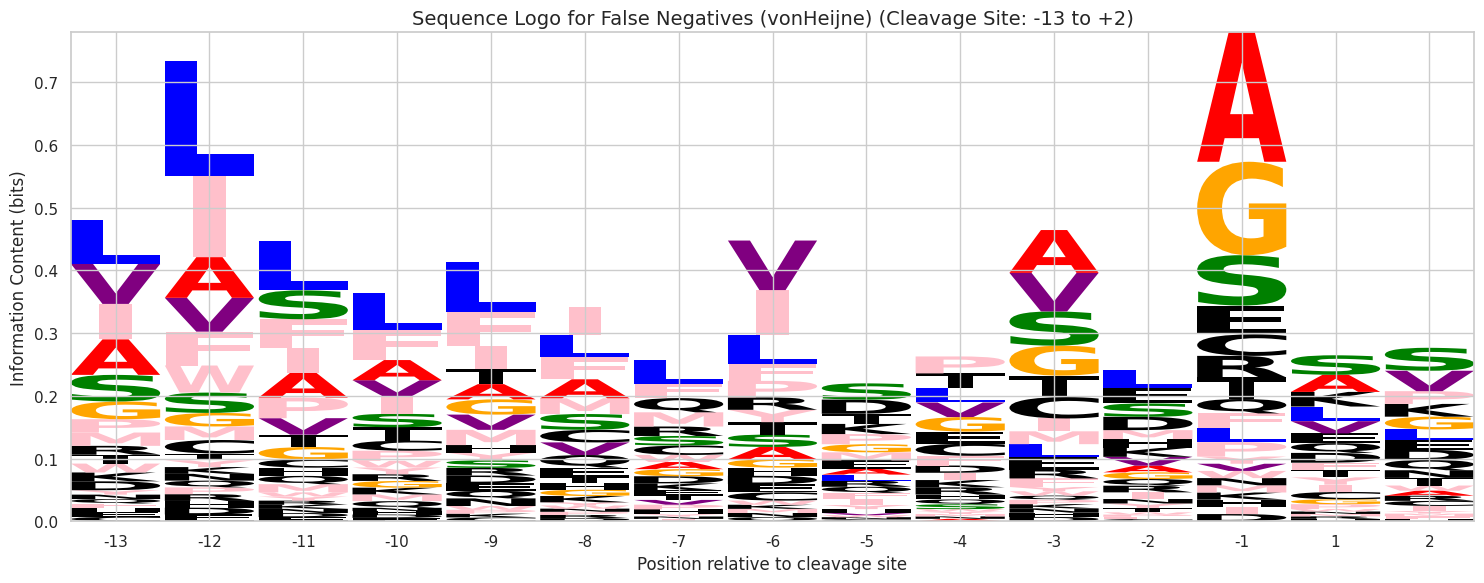

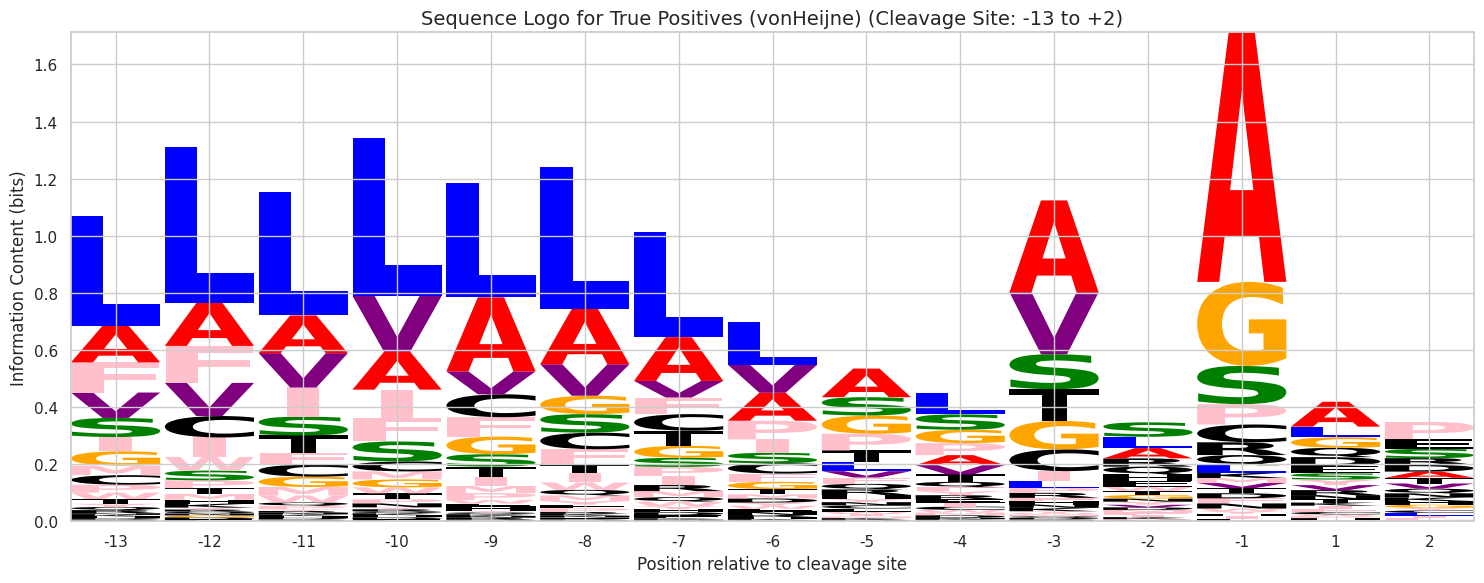

In [ ]:
def get_sequences_around_cleavage(fasta_data_dict, df_positive, upstream_offset=13, downstream_offset=2):
    extracted_sequences = []
    expected_window_length = upstream_offset + downstream_offset

    for index, row in df_positive.iterrows():
        protein_id = row['ID']
        cleavage_site_1idx = int(row['Cleavage']) # Cast to int here

        if protein_id in fasta_data_dict:
            full_seq = fasta_data_dict[protein_id]
            slice_start_0idx = cleavage_site_1idx - upstream_offset
            slice_end_0idx_exclusive = cleavage_site_1idx + downstream_offset

            segment_chars = []
            for i in range(slice_start_0idx, slice_end_0idx_exclusive):
                if 0 <= i < len(full_seq):
                    segment_chars.append(full_seq[i])
                else:
                    segment_chars.append('X')

            if len(segment_chars) == expected_window_length:
                extracted_sequences.append(''.join(segment_chars))

    return extracted_sequences

def read_fasta_to_dict(fasta_filename):
    sequences = {}
    current_id = None
    current_seq_lines = []
    with open(fasta_filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if current_id and current_seq_lines:
                    sequences[current_id] = ''.join(current_seq_lines)
                current_id = line[1:]
                current_seq_lines = []
            else:
                current_seq_lines.append(line)
        if current_id and current_seq_lines:
            sequences[current_id] = ''.join(current_seq_lines)
    return sequences

# Load full FASTA sequences
full_positive_fasta_sequences = read_fasta_to_dict('positive.fasta')


# Extract False Negatives and True Positives
FN_vh_df = vonHeijne[(vonHeijne['Class'] == 1) & (vonHeijne['Prediction'] == 0)]
TP_vh_df = vonHeijne[(vonHeijne['Class'] == 1) & (vonHeijne['Prediction'] == 1)]
print('False Negatives (FN):', FN_vh_df.shape)
print('True Positives (TP):', TP_vh_df.shape)

# Define custom color mapping by chemical properties
color_map = {
    'D': 'black', 'E': 'black', 'K': 'black', 'R': 'black',
    'T': 'black', 'C': 'black', 'N': 'black', 'Q': 'black', 'H': 'black',
    'S': 'green',
    'F': 'pink', 'W': 'pink', 'Y': 'pink',
    'V': 'purple',
    'G': 'orange',
    'A': 'red',
    'L': 'blue',
    'P': 'pink', 'I': 'pink', 'M': 'pink',
    'X': 'gray'
}

x_labels = [str(i) for i in range(-13, 0)] + [str(i) for i in range(1, 3)]

# Datasets to plot
logo_datasets = {
    'False Negatives (vonHeijne)': FN_vh_df,
    'True Positives (vonHeijne)': TP_vh_df,
}

# Extract windows, build info matrices and plot for each dataset
for title_label, df_pos in logo_datasets.items():
    cleavage_sequences = get_sequences_around_cleavage(
        full_positive_fasta_sequences, df_pos, upstream_offset=13, downstream_offset=2
    )
    counts_df = lm.alignment_to_matrix(sequences=cleavage_sequences, to_type='counts', pseudocount=0)
    info_df = lm.transform_matrix(counts_df, from_type='counts', to_type='information')
    fig, ax = plt.subplots(figsize=(15, 6))
    logo = lm.Logo(info_df, color_scheme=color_map, ax=ax)
    logo.ax.set_title(f'Sequence Logo for {title_label} (Cleavage Site: -13 to +2)', fontsize=14)
    logo.ax.set_xlabel('Position relative to cleavage site', fontsize=12)
    logo.ax.set_ylabel('Information Content (bits)', fontsize=12)
    logo.ax.set_xticks(range(info_df.shape[0]))
    logo.ax.set_xticklabels(x_labels)
    plt.tight_layout()
    plt.show()

In general the conservation is lower in the false negatives because they are below one bit, while in the original they are over the 1 bit. The original AxA site and the leucine at the beginning is less conserved, the more frequent residues are a bit diverse and the distribution of them is more uniform than in the original one. The residues more conserved are the hydrophobic ones but are less conserved than in the original.

## **SVM: composition of Train Positive, Benchmark False Positive and Benchmark True Positive**

### Handcraft-Feature

In [ ]:
custom_palette=['royalblue','purple','hotpink']

In [ ]:
def calculate_composition(dataframe):
  AA = {}
  total_count = 0

  for index, row in dataframe.iterrows():
    seq = row['Sequence'][:23]
    for char in seq:
      AA[char] = AA.get(char, 0) + 1
      total_count += 1

  for char in AA:
    AA[char] = round(AA[char] / total_count * 100, 2)

  return AA

Train Positive: (881, 33)
Benchmark True Positive: (191, 38)
Benchmark False Negative: (29, 38)
   Train Positive  Benchmark TP  Benchmark FN
M            6.26          6.24          6.00
A           13.28         14.02         10.79
G            5.61          5.76          6.00
L           21.29         22.04         12.89
S            7.41          6.97          8.55
R            3.16          2.91          6.30
T            4.73          4.30          5.25
P            4.21          4.33          5.70
C            2.82          3.26          2.25
K            2.39          2.60          3.30
V            8.25          7.51          8.10
W            1.72          1.50          1.95
F            5.14          5.21          5.40
Q            2.29          2.19          2.25
E            1.76          1.80          2.85
N            1.21          1.02          2.25
I            4.53          4.80          6.00
H            1.25          1.16          1.35
D            1.37          1.3

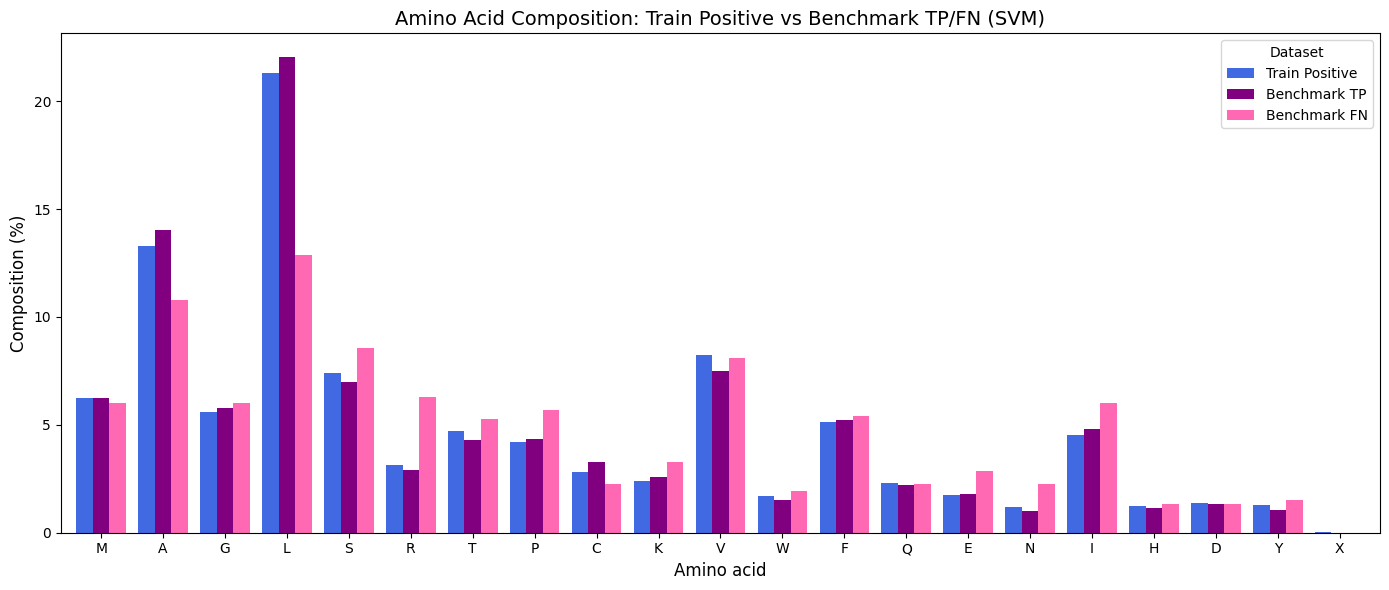

In [ ]:
col = ['ID', 'Set', 'Class', 'Sequence', 'G', 'A', 'V', 'P', 'L', 'I', 'M', 'F', 'W', 'Y', 'S', 'T', 'C', 'N', 'Q', 'H', 'D', 'E', 'K', 'R', 'X', 'hp_max', 'hp_mean', 'ah_max', 'ah_mean', 'tm_max', 'tm_mean', 'ch_max', 'ch_pos']

svm_pos_train_df = pd.read_csv('svm_pos_train.tsv', sep='\t', header=None, names=col)

TP_svm_df = svm[(svm['Class'] == 1) & (svm['Prediction'] == 1)]
FN_svm_df = svm[(svm['Class'] == 1) & (svm['Prediction'] == 0)]

print('Train Positive:', svm_pos_train_df.shape)
print('Benchmark True Positive:', TP_svm_df.shape)
print('Benchmark False Negative:', FN_svm_df.shape)

train_comp = calculate_composition(svm_pos_train_df)
tp_comp = calculate_composition(TP_svm_df)
fn_comp = calculate_composition(FN_svm_df)

comparison_df = pd.DataFrame({
  'Train Positive': train_comp,
  'Benchmark TP': tp_comp,
  'Benchmark FN': fn_comp,
}).fillna(0.0)

print(comparison_df)

ax = comparison_df.plot(kind='bar', figsize=(14, 6), width=0.8, color=custom_palette)
ax.set_xlabel('Amino acid', fontsize=12)
ax.set_ylabel('Composition (%)', fontsize=12)
ax.set_title('Amino Acid Composition: Train Positive vs Benchmark TP/FN (SVM)', fontsize=14)
ax.legend(title='Dataset')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### ESM-2 Embedding

Train Positive: (881, 4)
Benchmark True Positive: (204, 9)
Benchmark False Negative: (16, 9)
   Train Positive  Benchmark TP  Benchmark FN
A           13.28         13.85         10.33
C            2.82          3.20          2.17
D            1.37          1.24          2.45
E            1.76          1.85          2.99
F            5.14          5.35          3.80
G            5.61          5.82          5.43
H            1.25          1.15          1.63
I            4.53          5.01          4.35
K            2.39          2.62          3.53
L           21.29         21.21         16.03
M            6.26          6.14          7.07
N            1.21          1.17          1.36
P            4.21          4.45          5.16
Q            2.29          2.24          1.63
R            3.16          2.98          8.15
S            7.41          7.25          6.25
T            4.73          4.41          4.62
V            8.25          7.57          7.88
W            1.72          1.34  

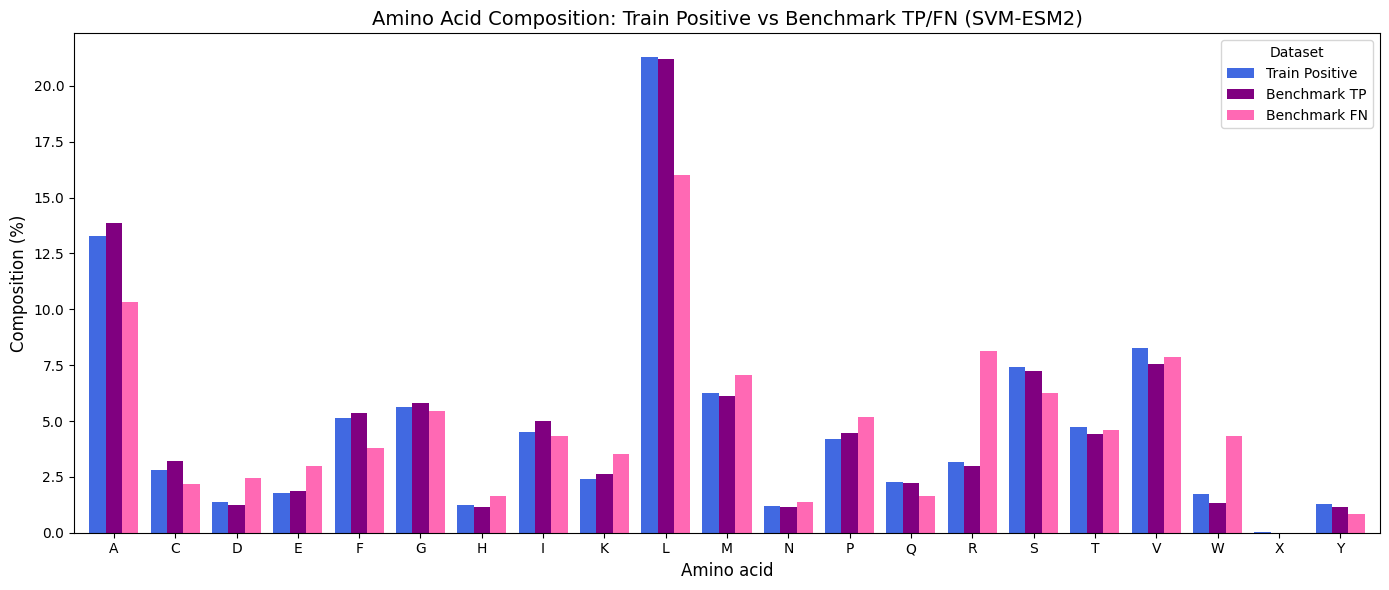

In [ ]:
# Upload the ESM2 training positive dataframe
col_esm = ['ID', 'Set', 'Class', 'Sequence']
esm_pos_train_df = pd.read_csv('esm_pos_train.tsv', sep='\t', header=None, names=col_esm)

# Extract True Positives and False Negatives from the ESM2 benchmark
TP_esm_df = svm_esm2[(svm_esm2['Class'] == 1) & (svm_esm2['Prediction'] == 1)]
FN_esm_df = svm_esm2[(svm_esm2['Class'] == 1) & (svm_esm2['Prediction'] == 0)]

print('Train Positive:', esm_pos_train_df.shape)
print('Benchmark True Positive:', TP_esm_df.shape)
print('Benchmark False Negative:', FN_esm_df.shape)

train_comp_esm = calculate_composition(esm_pos_train_df)
tp_comp_esm = calculate_composition(TP_esm_df)
fn_comp_esm = calculate_composition(FN_esm_df)

comparison_df_esm = pd.DataFrame({
  'Train Positive': train_comp_esm,
  'Benchmark TP': tp_comp_esm,
  'Benchmark FN': fn_comp_esm,
}).fillna(0.0).sort_index()

print(comparison_df_esm)

ax = comparison_df_esm.plot(kind='bar', figsize=(14, 6), width=0.8, color=custom_palette)
ax.set_xlabel('Amino acid', fontsize=12)
ax.set_ylabel('Composition (%)', fontsize=12)
ax.set_title('Amino Acid Composition: Train Positive vs Benchmark TP/FN (SVM-ESM2)', fontsize=14)
ax.legend(title='Dataset')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **SVM: Length distributions of Train Positive, Benchmark False Negative and Benchmark True Positive**

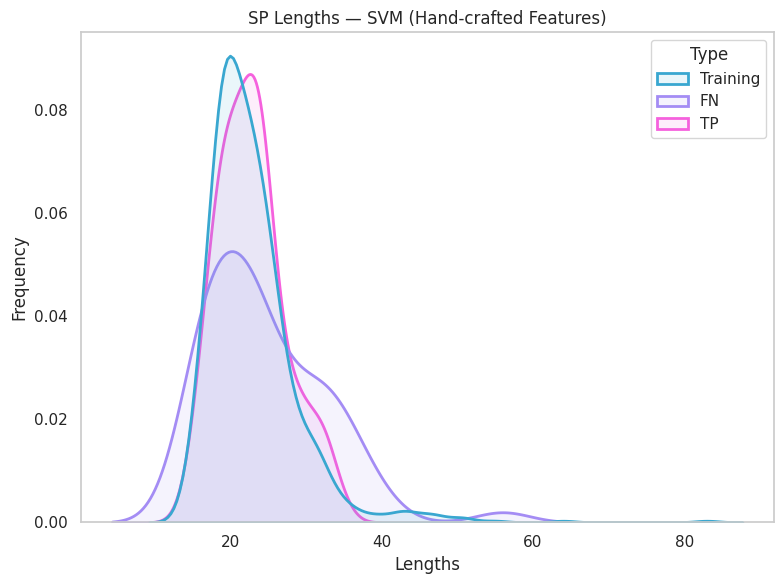

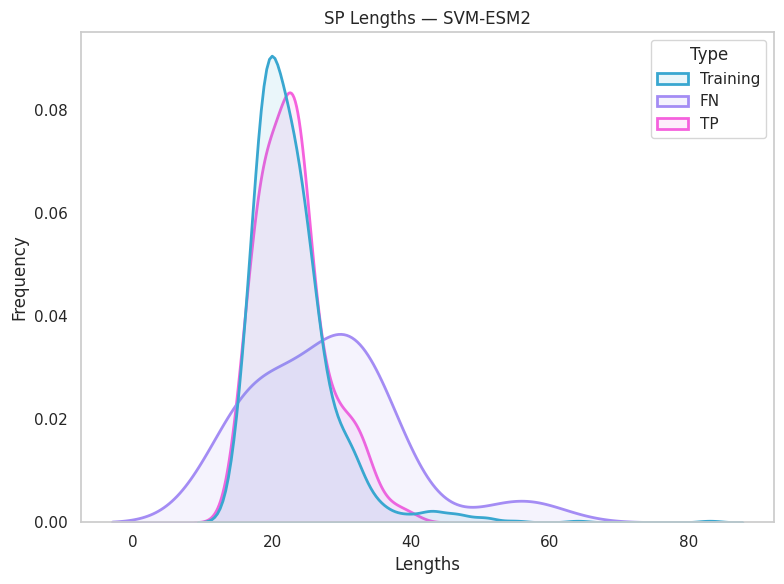

In [ ]:
def build_length_df(pos_train_df, tp_df, fn_df):
  train_filt = pos_train_df[['ID', 'Cleavage']].copy()
  train_filt['Type'] = 'Training'

  tp_filt = tp_df[['ID', 'Cleavage']].copy()
  tp_filt['Type'] = 'TP'

  fn_filt = fn_df[['ID', 'Cleavage']].copy()
  fn_filt['Type'] = 'FN'

  return pd.concat([train_filt, fn_filt, tp_filt], axis=0)


def plot_length_distribution(df_length, title):
  plt.figure(figsize=(8, 6))
  palette = sns.color_palette("husl", 8)
  sns.kdeplot(data=df_length, x='Cleavage', hue='Type', common_norm=False,
              fill=True, alpha=0.1, palette=palette[5:], linewidth=2)
  plt.title(title)
  plt.xlabel('Lengths')
  plt.ylabel('Frequency')
  plt.tight_layout()
  plt.grid()
  plt.show()


# SVM (hand-crafted)
col_pos_train = ['ID', 'Species', 'Kingdom', 'Length', 'Cleavage', 'Set']
pos_train_svm = pd.read_csv('cv_pos.tsv', sep='\t', header=None, names=col_pos_train)

df_length_svm = build_length_df(pos_train_svm, TP_svm_df, FN_svm_df)

plot_length_distribution(df_length_svm, 'SP Lengths — SVM (Hand-crafted Features)')

# SVM-ESM2
pos_train_esm = pd.read_csv('cv_pos.tsv', sep='\t', header=None, names=col_pos_train)

df_length_esm = build_length_df(pos_train_esm, TP_esm_df, FN_esm_df)

plot_length_distribution(df_length_esm, 'SP Lengths — SVM-ESM2')

### SVM-HandCrafted: Distribution of other features adopted

/tmp/ipykernel_13005/963591141.py:37: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=df_melted[df_melted['Feature'] == feature], x='Type', y='Value', palette=palette[5:], hue='Type')
/tmp/ipykernel_13005/963591141.py:37: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=df_melted[df_melted['Feature'] == feature], x='Type', y='Value', palette=palette[5:], hue='Type')
/tmp/ipykernel_13005/963591141.py:37: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=df_melted[df_melted['Feature'] == feature], x='Type', y='Value', palette=palette[5:], hue='Type')
/tmp/ipykernel_13005/963591141.py:37: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.boxplot(data=df_melted[df_melted['Feature'] == feature], x='Type', y='Value', palette=palette[5:], hue='Type')
/tmp

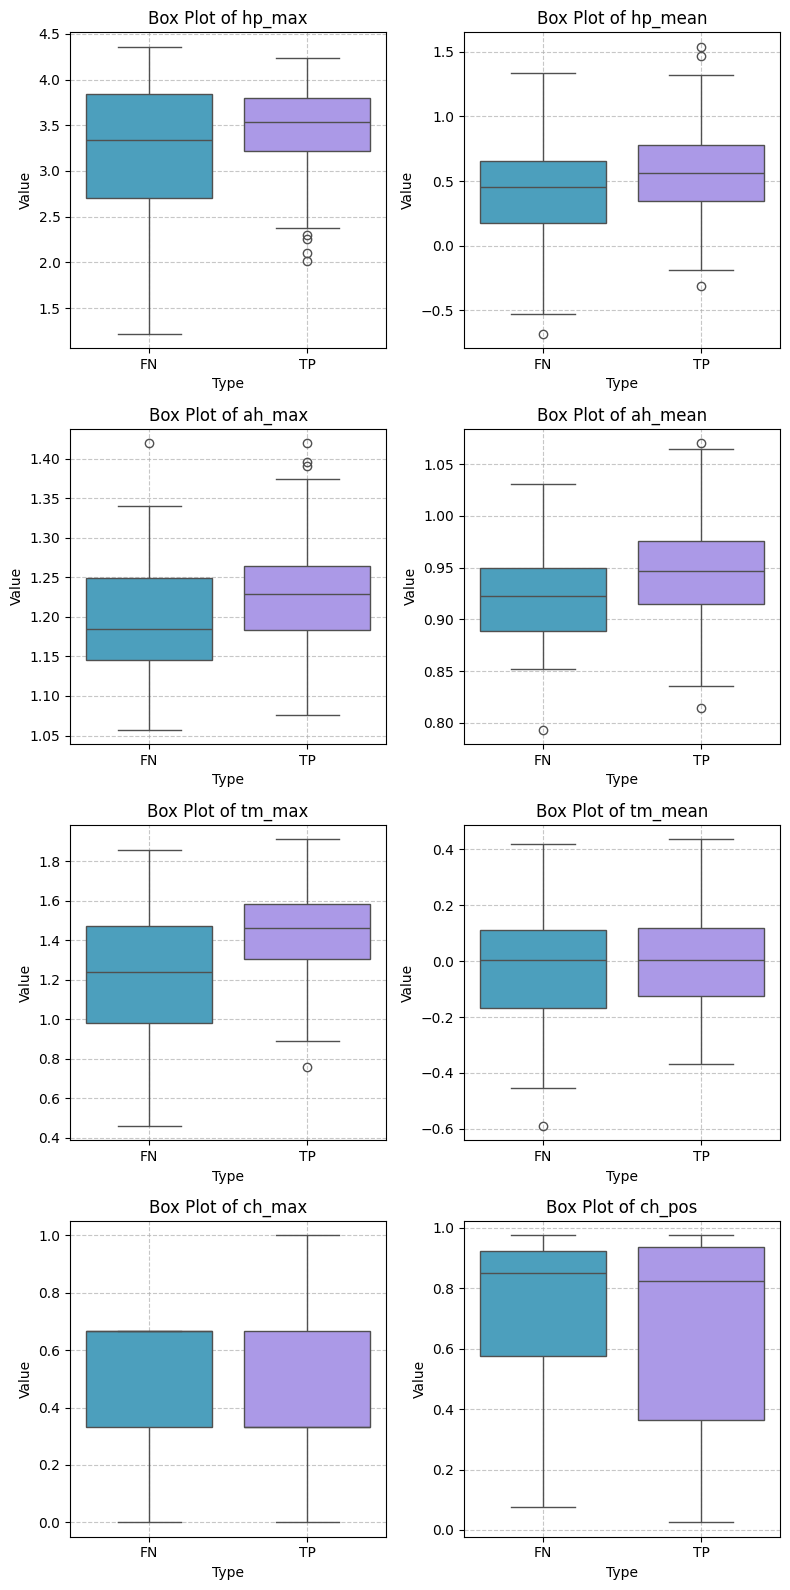

In [ ]:
def extract_df(model, df):
  mapping = {
        'hp': ['hp_max', 'hp_mean'],
        'ah': ['ah_max', 'ah_mean'],
        'tm': ['tm_max', 'tm_mean'],
        'ch': ['ch_max', 'ch_pos']
  }
  in_col = []
  for m in model:
    in_col.extend(mapping[m])
  return df[in_col].copy()

selected_features = ['hp', 'ah', 'tm', 'ch']

TP_svm_df_filt = extract_df(selected_features, TP_svm_df)
FN_svm_df_filt = extract_df(selected_features, FN_svm_df)

TP_svm_df_filt['Type'] = 'TP'
FN_svm_df_filt['Type'] = 'FN'

df_box = pd.concat([FN_svm_df_filt, TP_svm_df_filt], axis=0)

df_melted = pd.melt(df_box, id_vars=['Type'],
                    value_vars=['hp_max', 'hp_mean', 'ah_max', 'ah_mean', 'tm_max', 'tm_mean', 'ch_max', 'ch_pos'],
                    var_name='Feature', value_name='Value')

plot_features = df_melted['Feature'].unique()
num_features = len(plot_features)
nrows = (num_features + 1) // 2
ncols = 2

palette = sns.color_palette("husl", 8)
plt.figure(figsize=(8, nrows * 4))

for i, feature in enumerate(plot_features):
  plt.subplot(nrows, ncols, i + 1)
  sns.boxplot(data=df_melted[df_melted['Feature'] == feature], x='Type', y='Value', palette=palette[5:], hue='Type')
  plt.title(f'Box Plot of {feature}')
  plt.xlabel('Type')
  plt.ylabel('Value')
  plt.grid(True, linestyle='--', alpha=0.7)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.tight_layout()
plt.show()